In [8]:
from gymnasium.wrappers import TimeLimit

from src.model.cnn import CustomCNN, CustomCNN_2
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import (
    DummyVecEnv, 
    VecNormalize,
    VecFrameStack, 
    VecTransposeImage
)

from src.mygym.lunar_lander import MyLunarLander
from src.wrapper.visual_wrapper import VisualWrapper, CropObservation, LunarLanderRewardEngineering
from src.wrapper.pendulum_wrapper import ResizeObservation

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets


In [9]:
def make_env(seed, **kwargs):
    def _init():
        env = MyLunarLander(
                        render_mode="rgb_array", 
                        continuous=True
                        )
        # env = LoggingWrapper(env)  # For debugging: log each step. Comment out by default
        env = VisualWrapper(env)
        env = TimeLimit(env, max_episode_steps=kwargs.get("episode_timesteps"))
        env = ResizeObservation(env, 
                                (kwargs.get("image_height"), 
                                 kwargs.get("image_width")))
        env = CropObservation(env, 
                                (kwargs.get("image_height"), 
                                 kwargs.get("image_width")),
                                width_center=kwargs.get("width_center"))
        
        env = LunarLanderRewardEngineering(env)
        env.reset(seed=seed)
        return env
    return _init

In [10]:
config = {
    "episode_timesteps": 1024,
    "image_height": 200,
    "image_width": 200,
    "width_center": 40,
    "n_stacked_frame": 4
}

env = DummyVecEnv([make_env(0, **config)])
# env = VecFrameStack(env, n_stack=config.get("n_stacked_frame"))
env = VecTransposeImage(env)
env = VecNormalize(env, norm_obs=False, norm_reward=True, clip_obs=10.0)

In [11]:
obs = env.reset()
obs.shape

(1, 3, 200, 80)

In [12]:
import numpy as np

np.squeeze(obs).shape

(3, 200, 80)

Shape: (200, 80, 3)


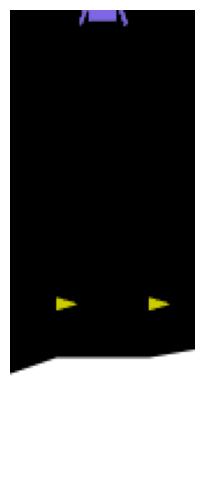

In [13]:
import matplotlib.pyplot as plt

def plot_obs(obs, title="", n_frame=4):
    if n_frame == 1:
        fig, ax = plt.subplots(figsize=(5, 6))
        tmp_obs = np.squeeze(obs)
        tmp_img = tmp_obs.transpose(1, 2, 0).astype(int)
        ax.set_title(title)
        ax.imshow(tmp_img)
        ax.axis("off")
    else:    
        fig, axes = plt.subplots(1, n_frame, figsize=(10, 5))

        tmp_obs = np.squeeze(obs)

        axes[0].set_title(title)
        for id, ax in enumerate(axes):
            tmp_img = tmp_obs[id*3: id*3+3, :, :].transpose(1, 2, 0).astype(int)
            ax.imshow(tmp_img)
            ax.axis("off")
    
    print("Shape:", tmp_img.shape)
plot_obs(obs, n_frame=1)

In [14]:
tmp_obs = np.squeeze(obs)
tmp_img = tmp_obs.transpose(1, 2, 0).astype(int)

In [15]:
import pandas as pd

log_fn = "../../run/ppo_vislunarlander_default/logs/ppo_vislunarlander_eval_default_seed_42.pkl"

with open(log_fn, "rb") as f:
    df = pd.read_pickle(f)
df

,state,action,reward,accumulated_reward
0,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.2284143, 0.98159665]]",[0.4871834],[0.4871834]
1,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.64581645, -0.88008195]]",[1.6534903],[2.1406736]
2,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-1.0, -0.20441301]]",[1.1782337],[3.3189073]
3,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[-1.0, 0.36885685]]",[1.135729],[4.454636]
4,[[[[ 0 0 0 0 0 0 0 0 0 0 ...,"[[0.19918928, 1.0]]",[-2.0080407],[2.4465954]
...,...,...,...,...
146,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.2703043, -1.0]]",[-3.8191776],[-180.01323]
147,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.058911264, 1.0]]",[-5.949293],[-185.96252]
148,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[-0.6807909, 1.0]]",[3.7481022],[-182.21442]
149,[[[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...,"[[0.6615903, 1.0]]",[35.951973],[-146.26245]


# Design new cost function filter

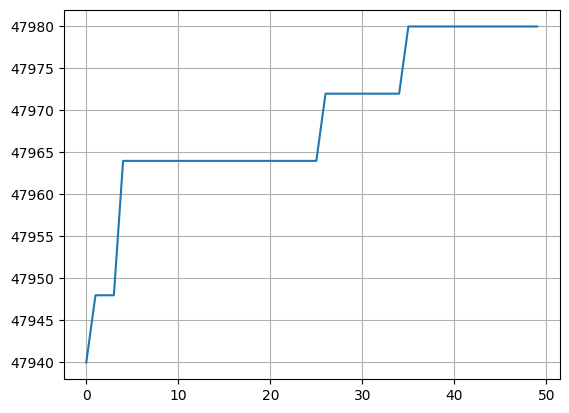

In [16]:
df.state[:2]

np.allclose(df.state[126], df.state[125], atol=20)
np.count_nonzero(np.isclose(df.state[130], df.state[125], atol=2))
# 200*200*3

atol_list = range(50)
count = [np.count_nonzero(np.isclose(df.state[130], df.state[111], atol=a)) for a in atol_list]

plt.plot(atol_list, count)
plt.grid("minor")

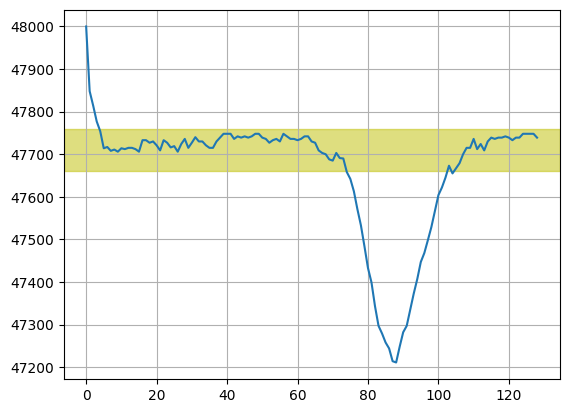

In [17]:
images_ids = range(129)
count = [np.count_nonzero(np.isclose(df.state[0], df.state[i], atol=7)) for i in images_ids]

plt.plot(images_ids, count)
plt.axhspan(47660, 47760, color="y", alpha=0.5)
plt.grid("minor")

Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)


/tmp/ipykernel_26621/413753629.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(5, 6))


Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)
Shape: (200, 80, 3)


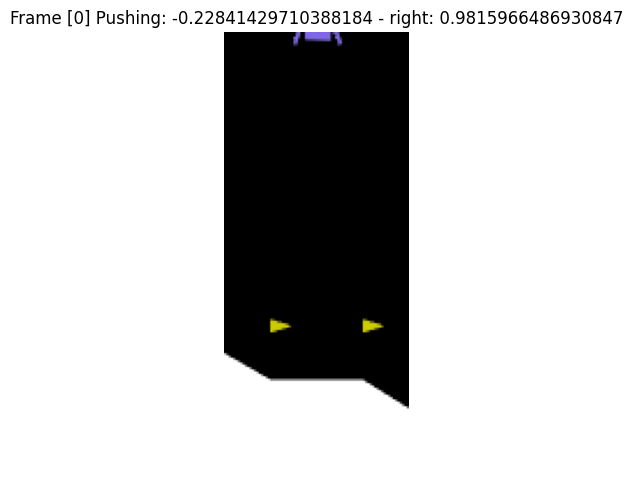

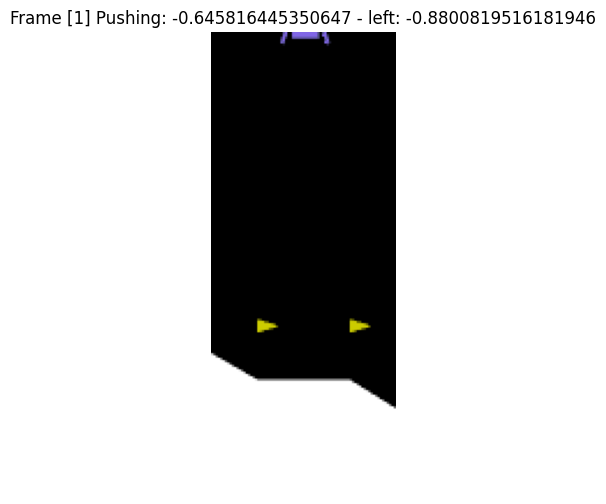

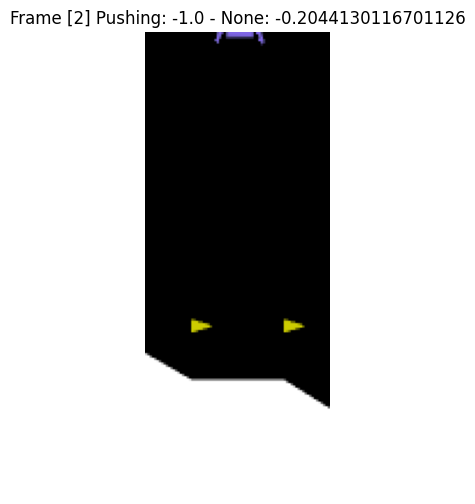

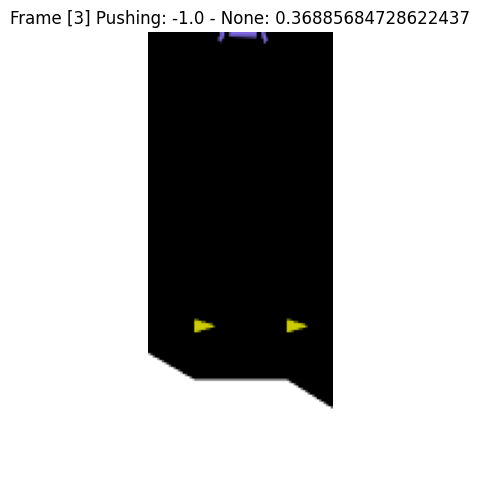

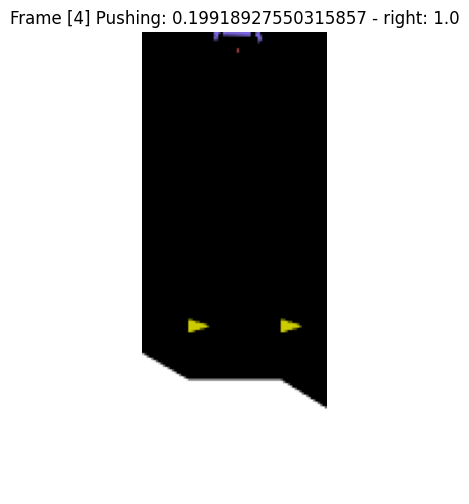

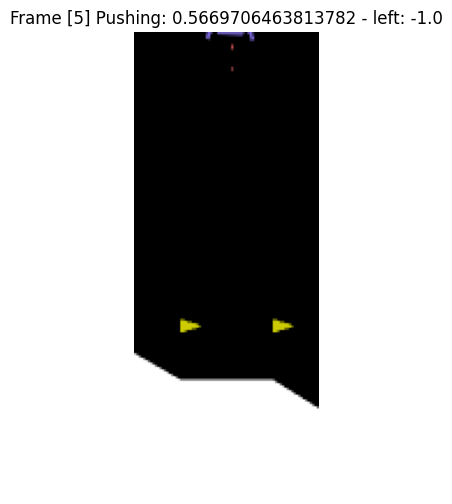

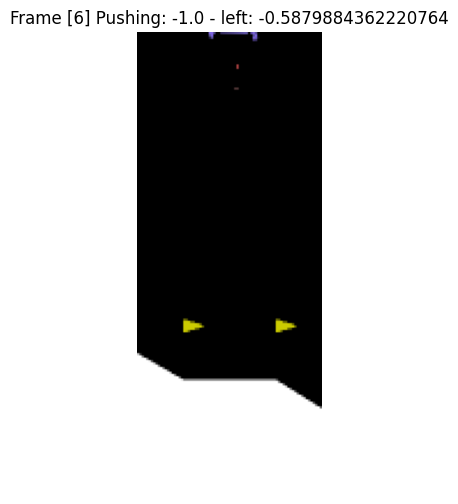

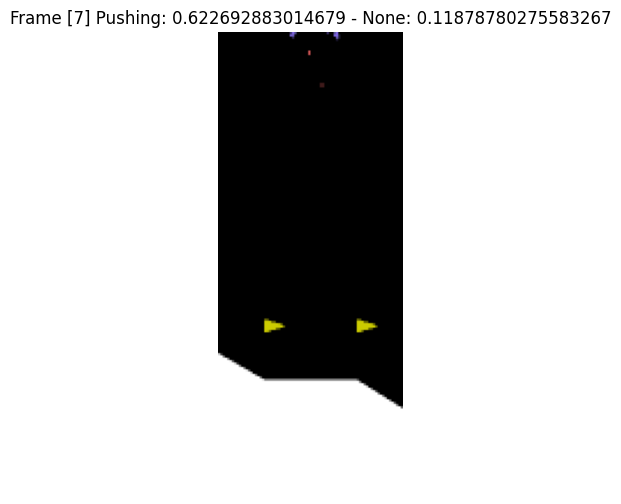

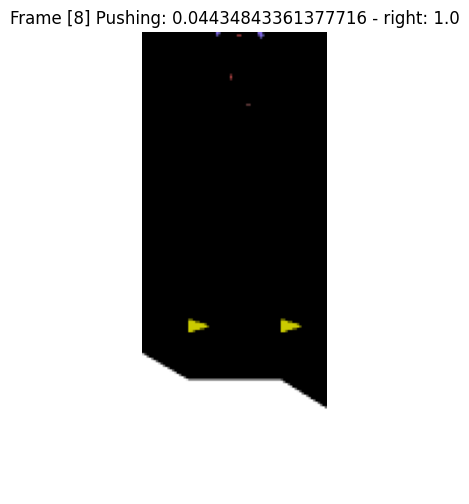

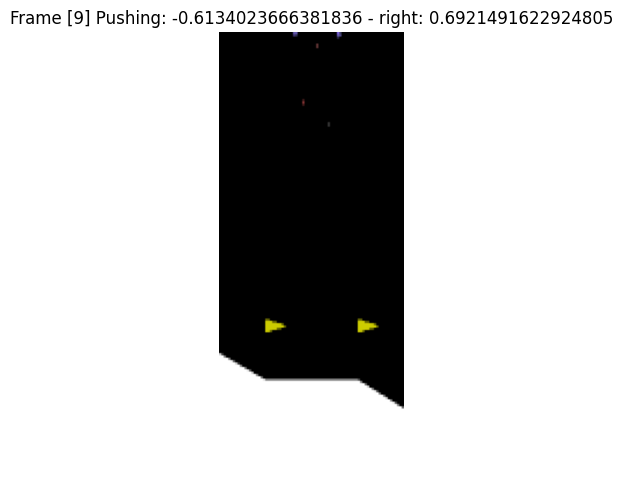

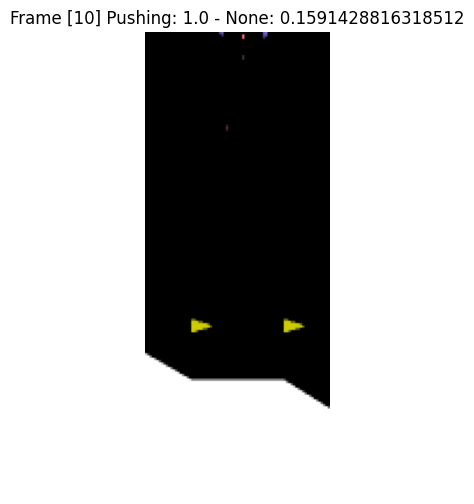

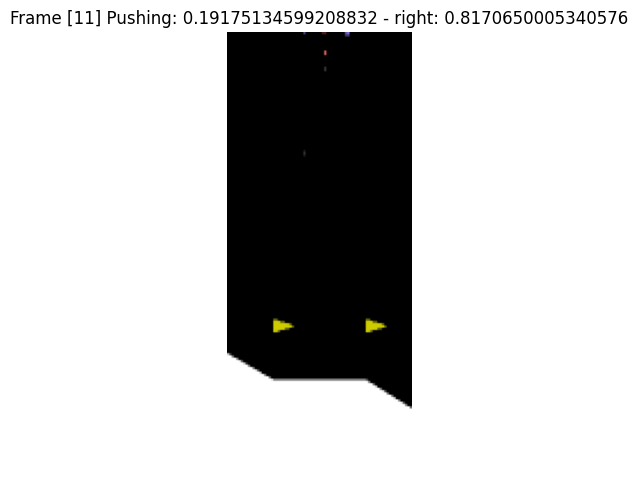

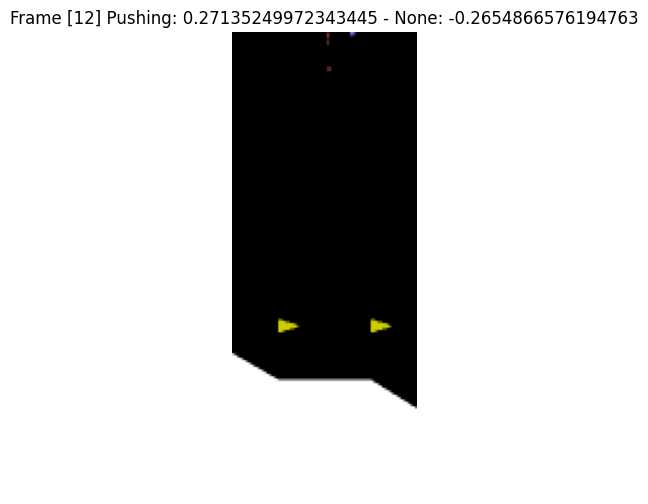

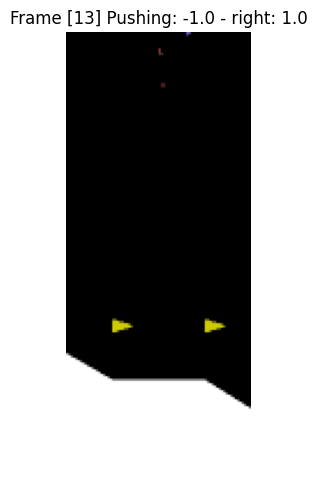

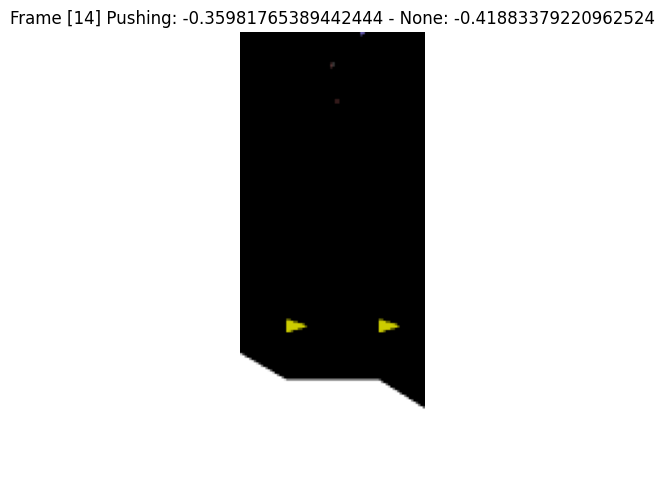

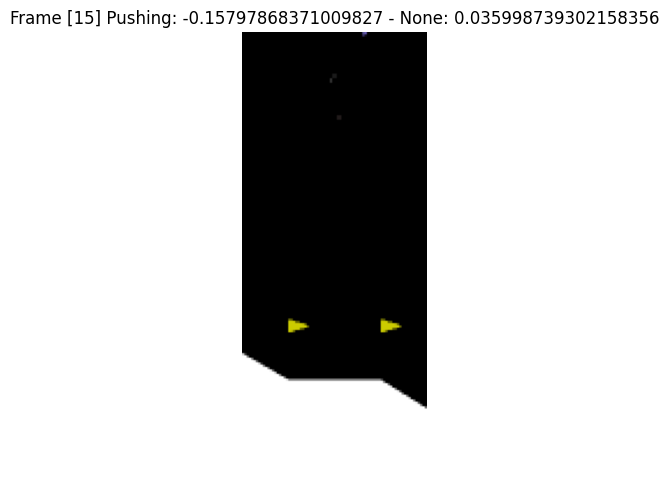

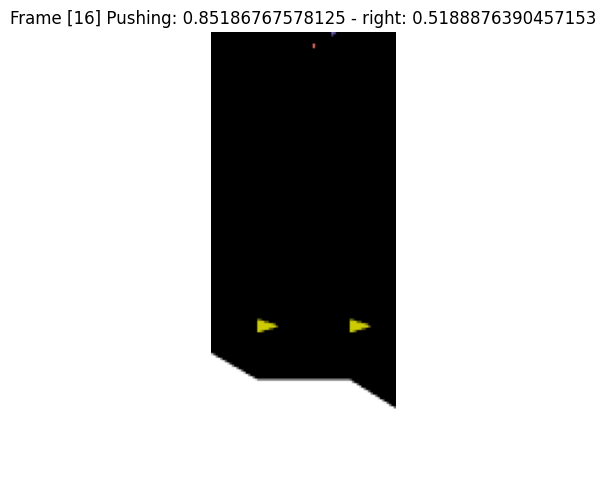

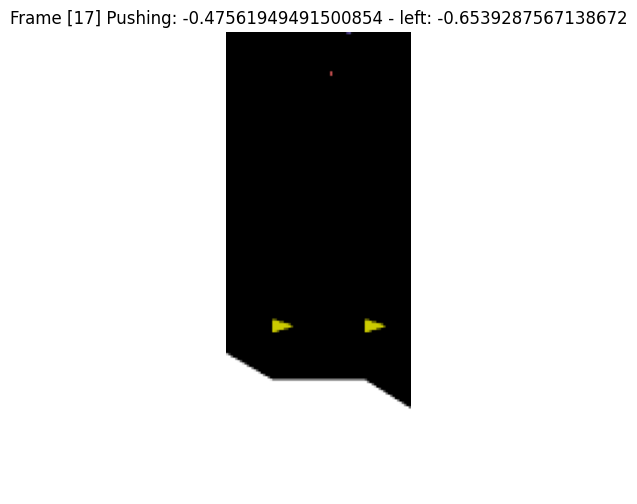

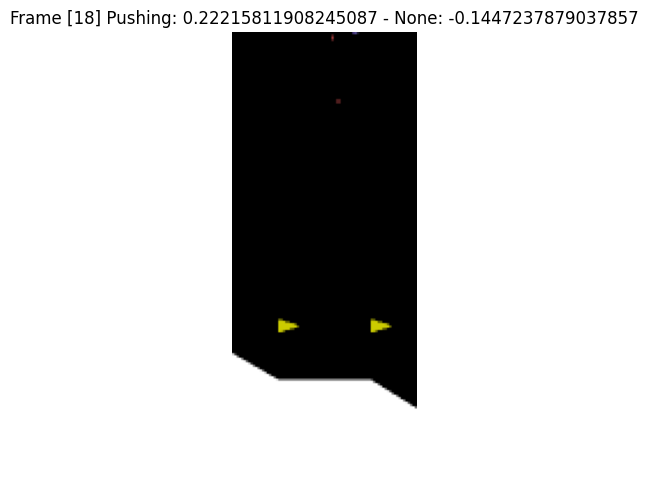

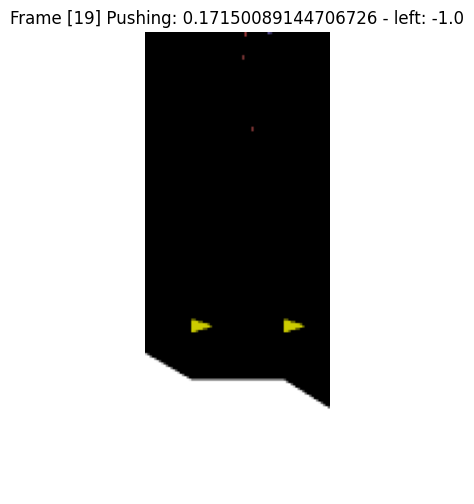

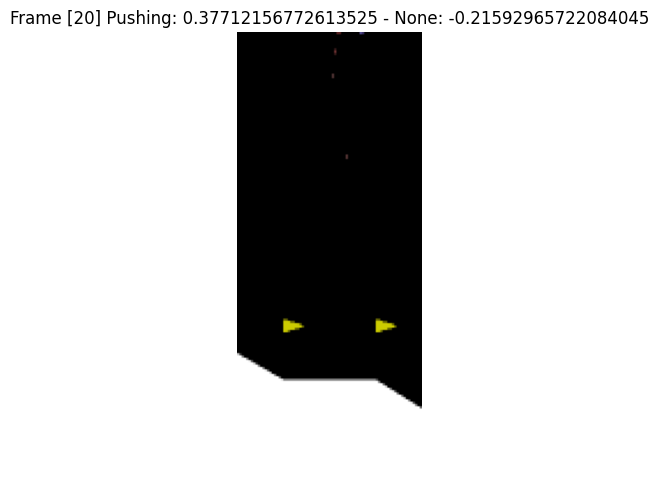

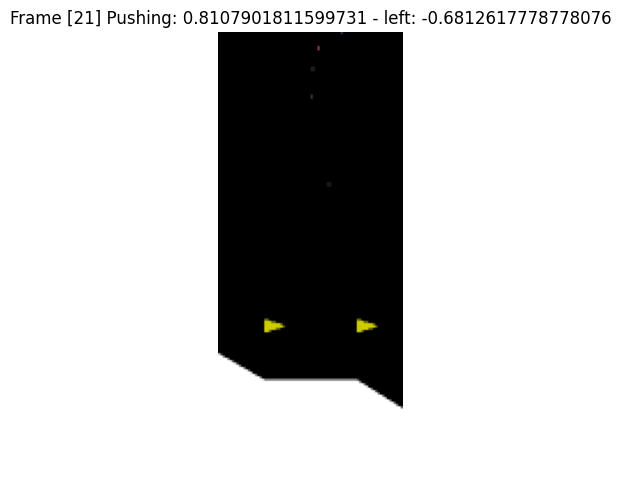

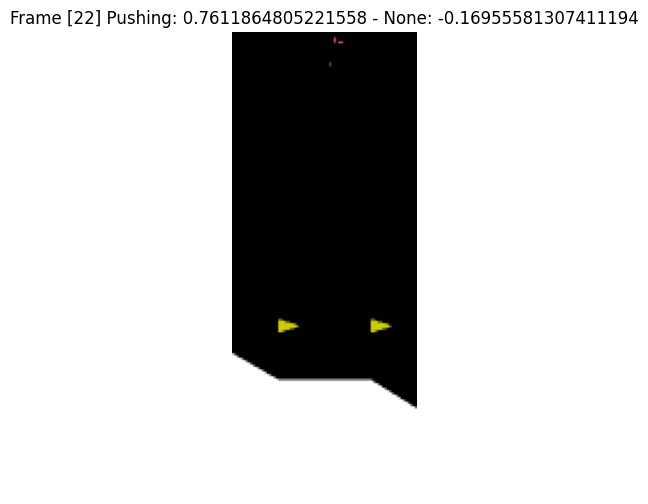

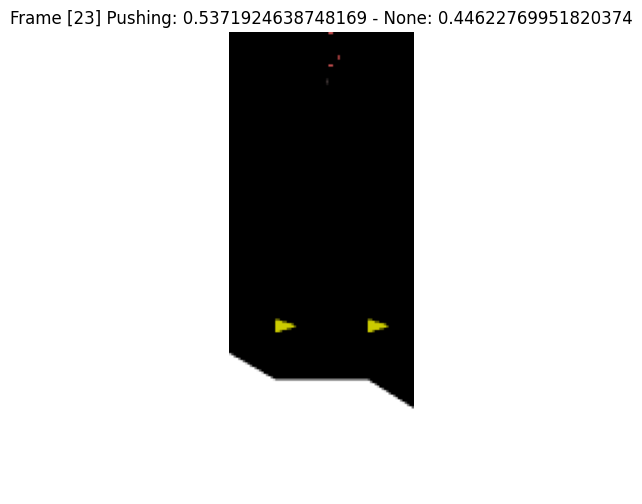

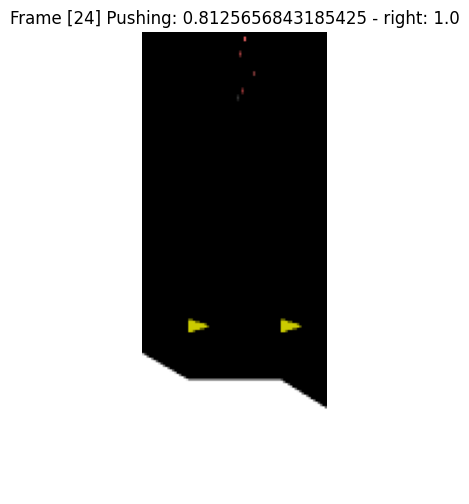

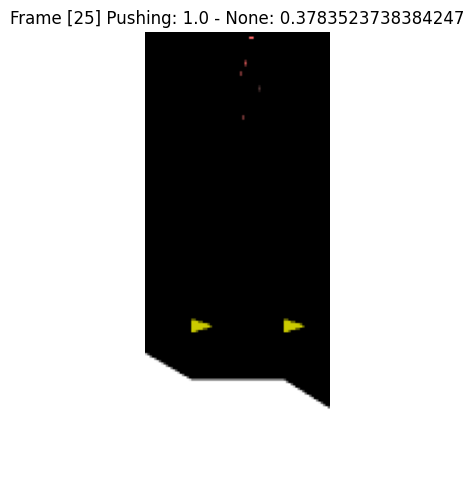

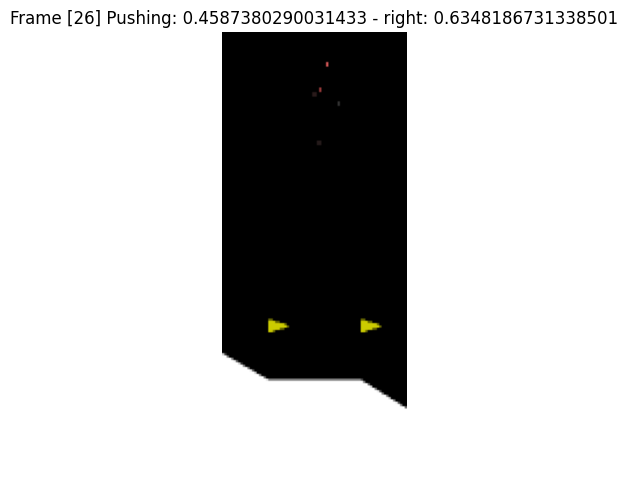

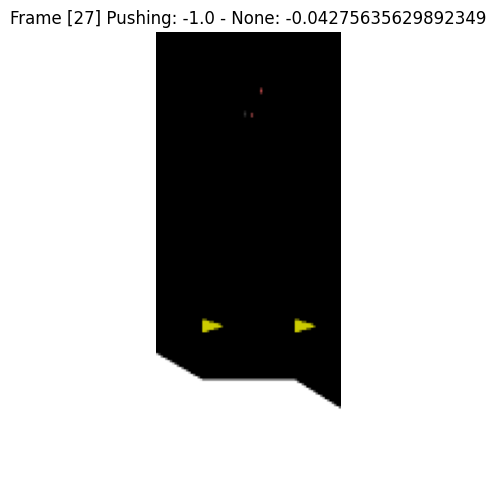

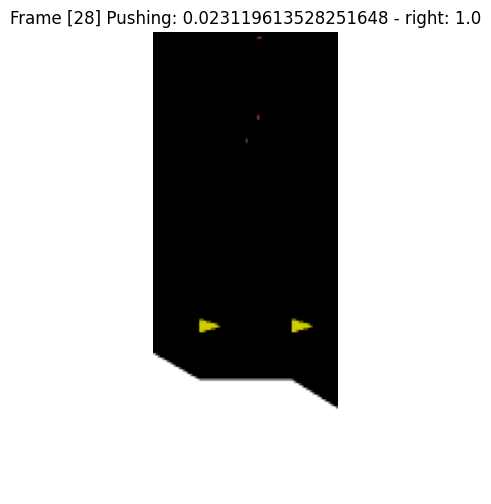

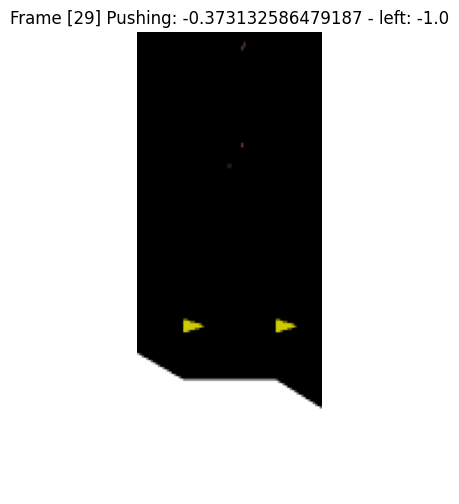

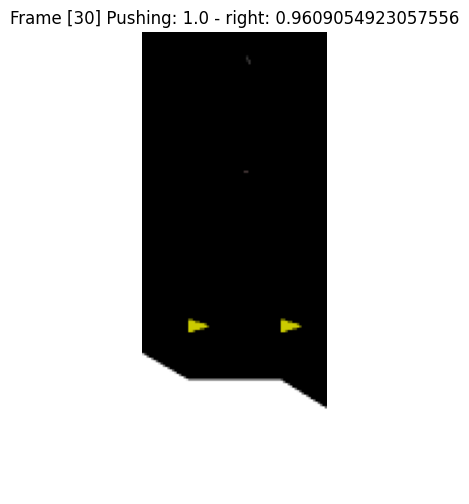

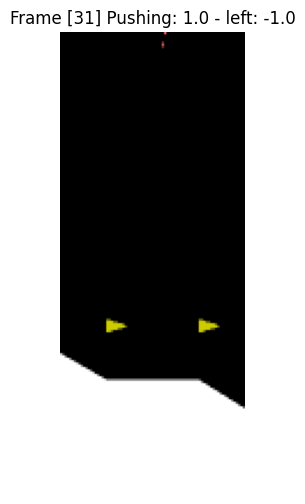

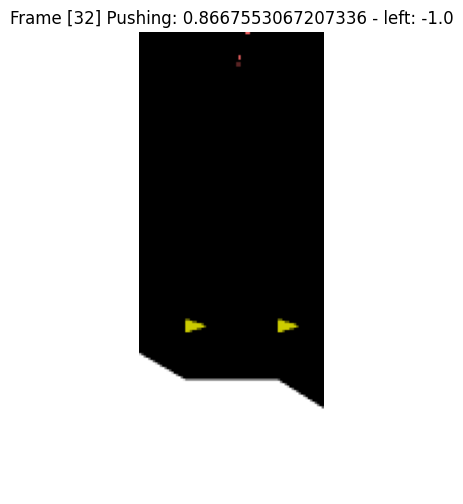

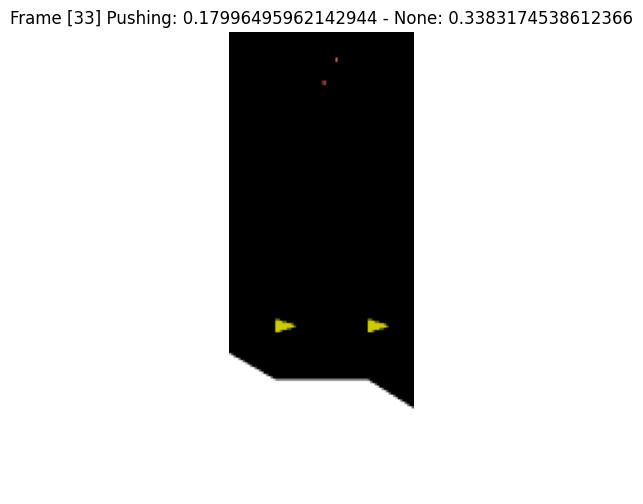

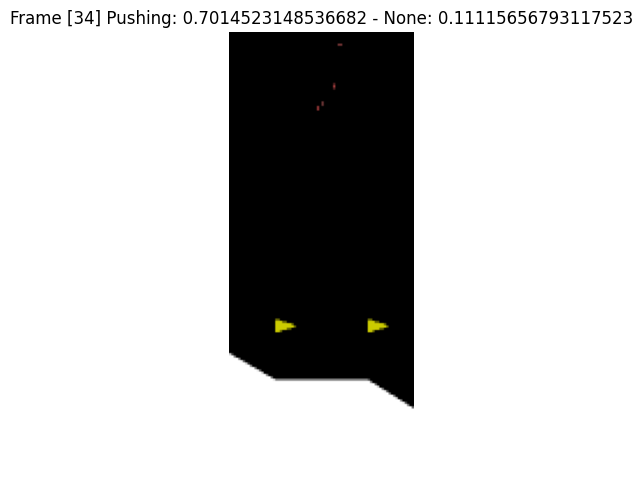

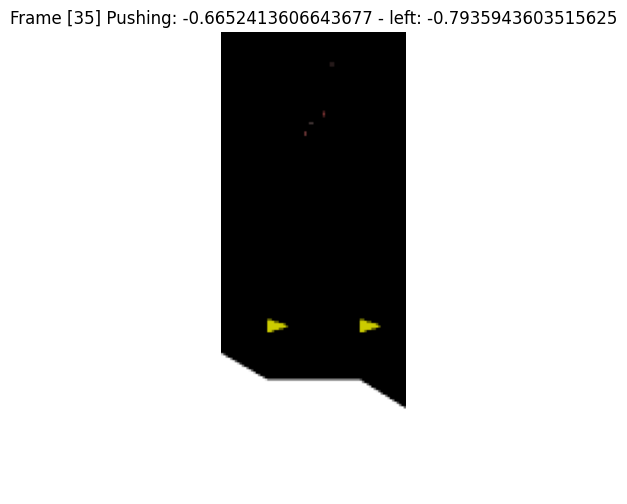

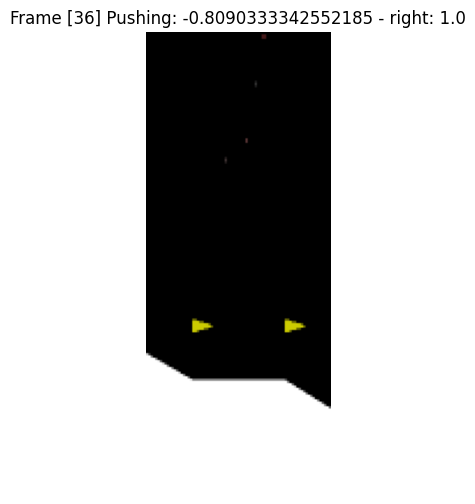

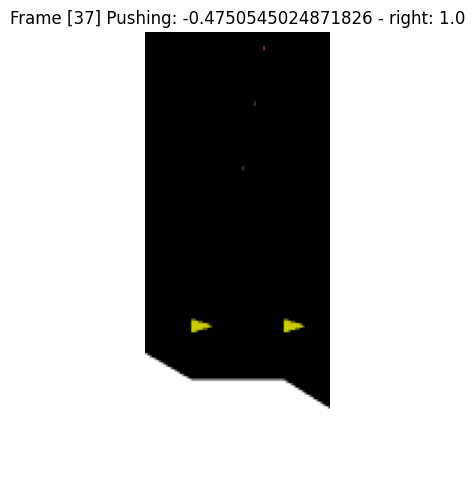

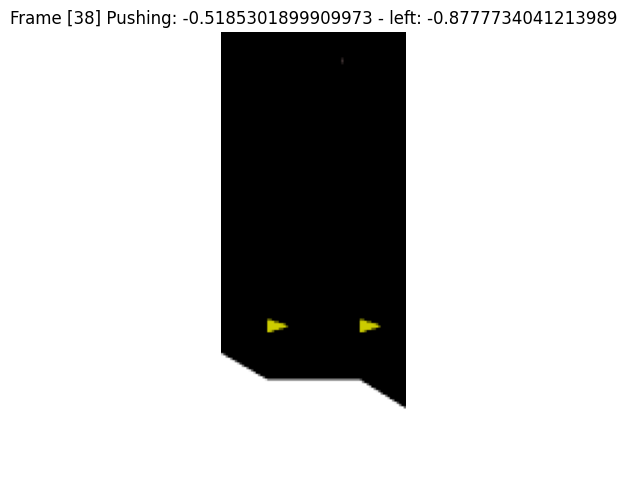

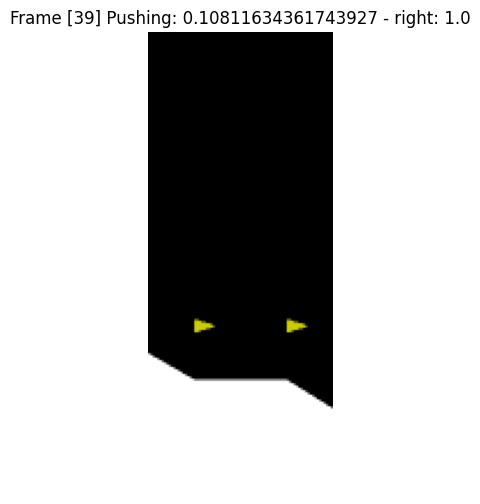

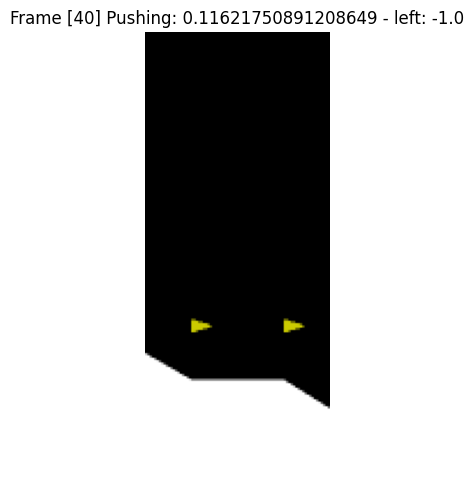

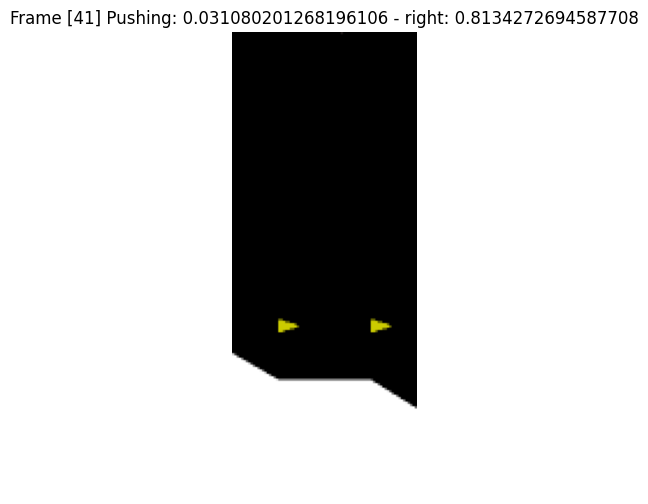

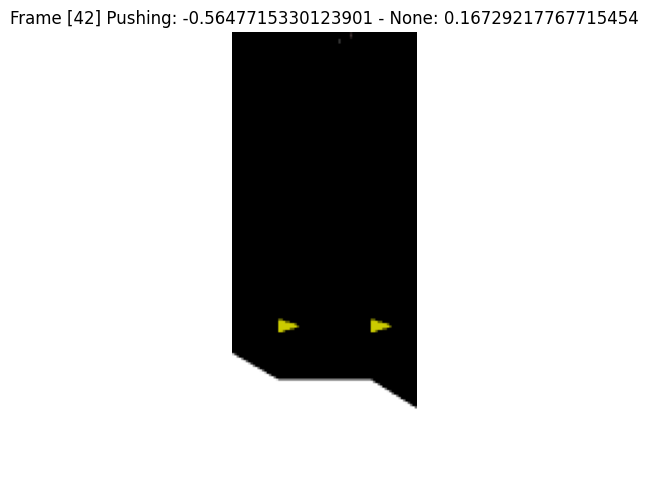

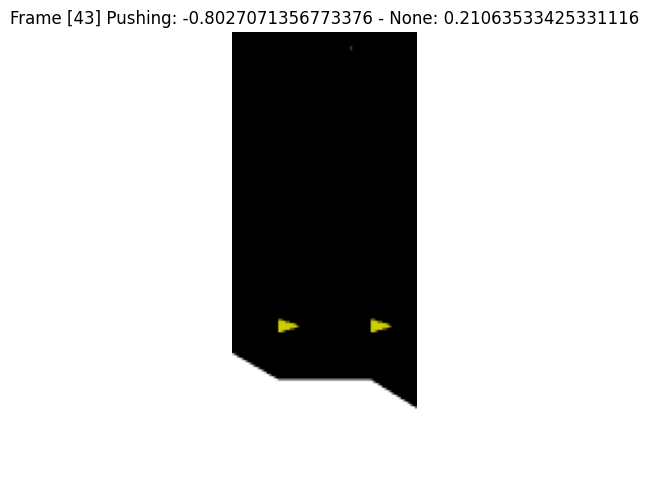

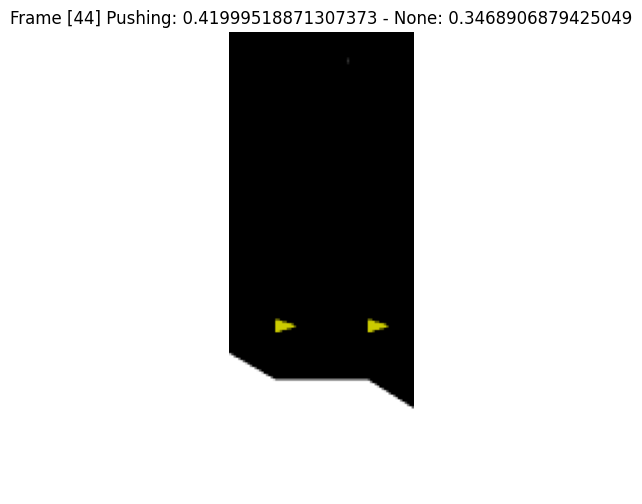

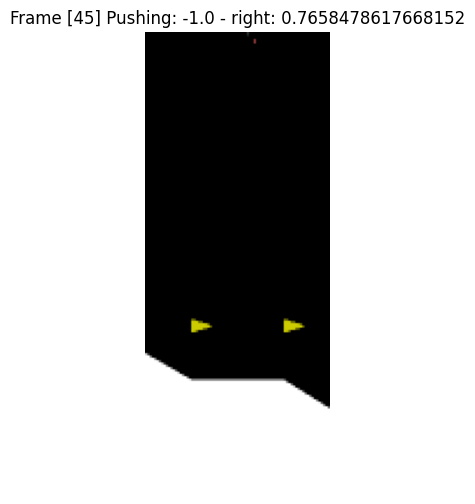

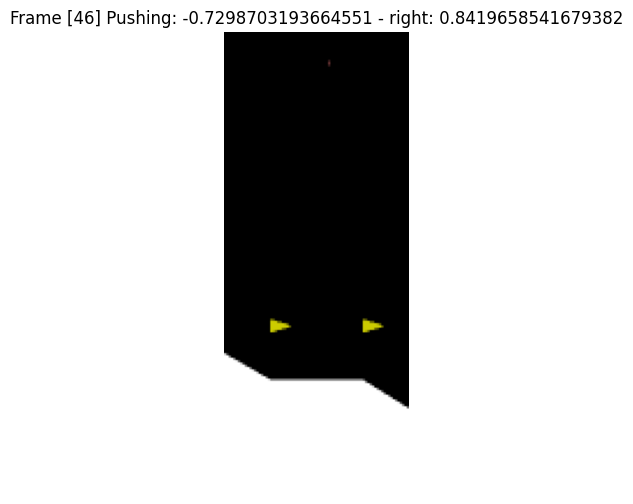

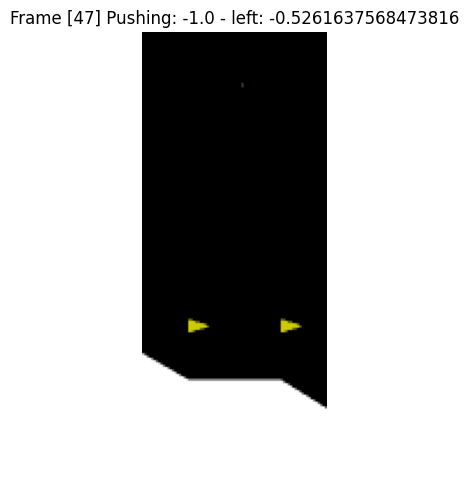

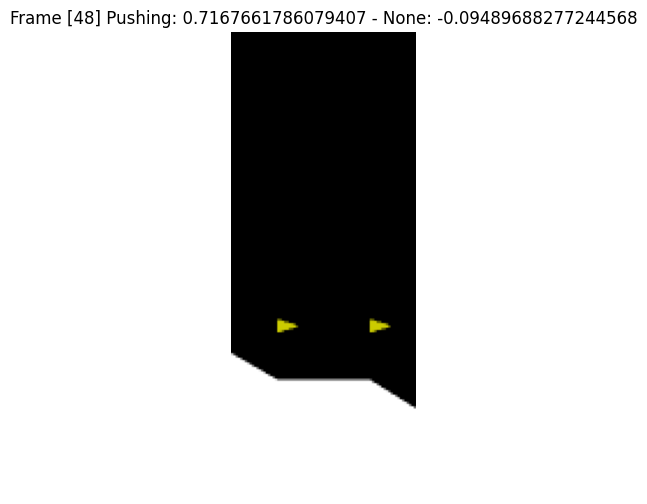

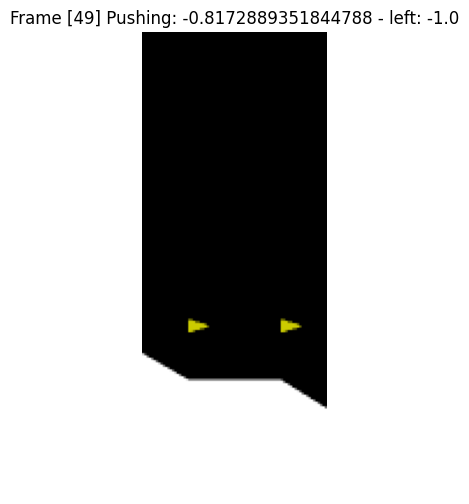

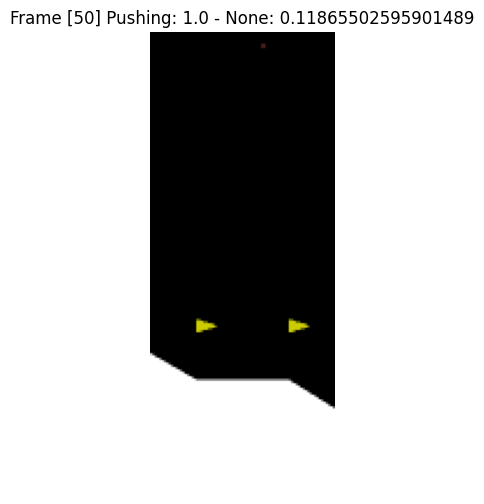

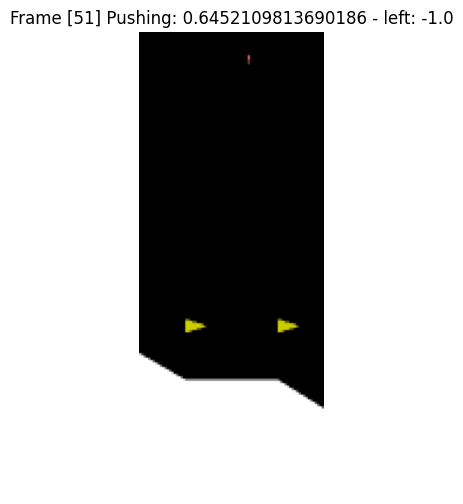

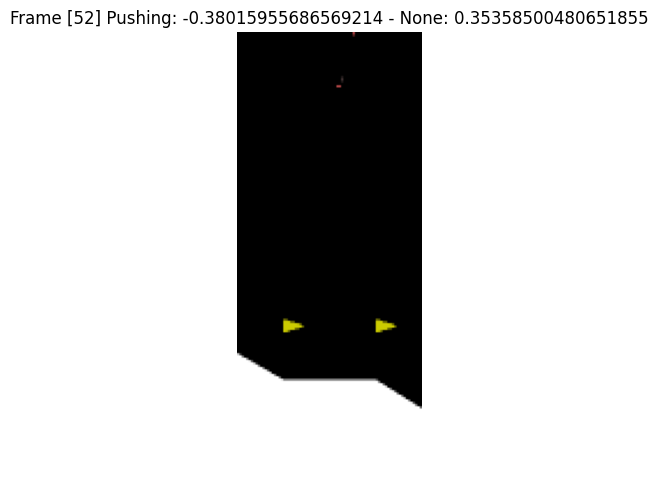

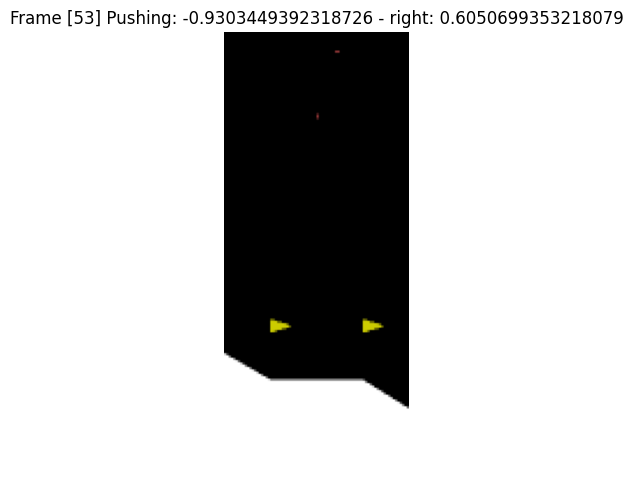

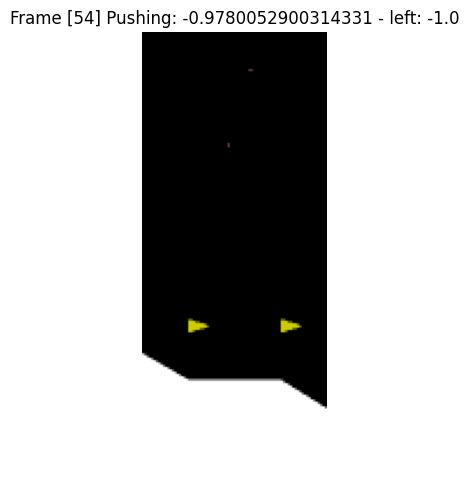

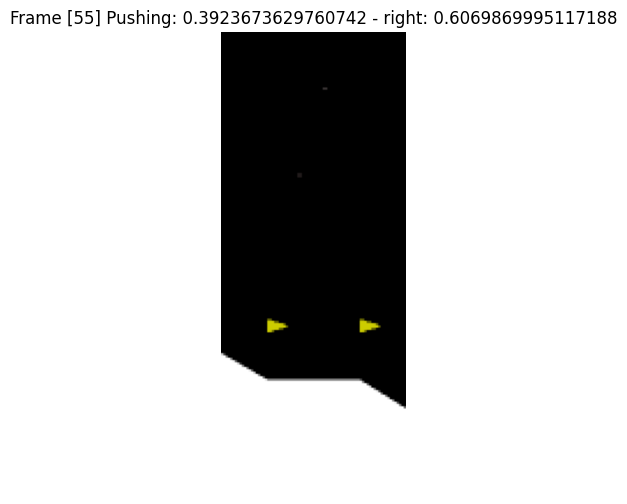

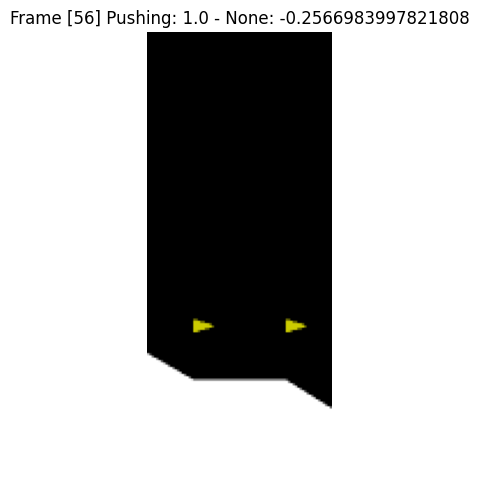

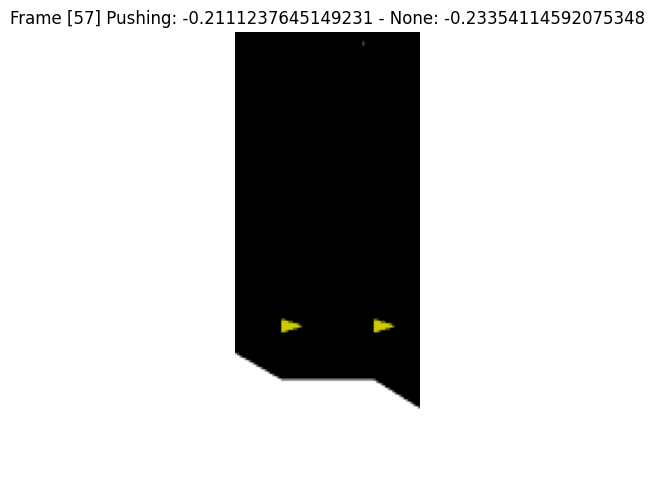

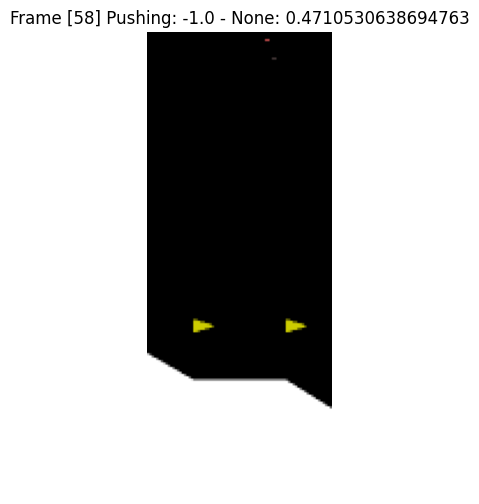

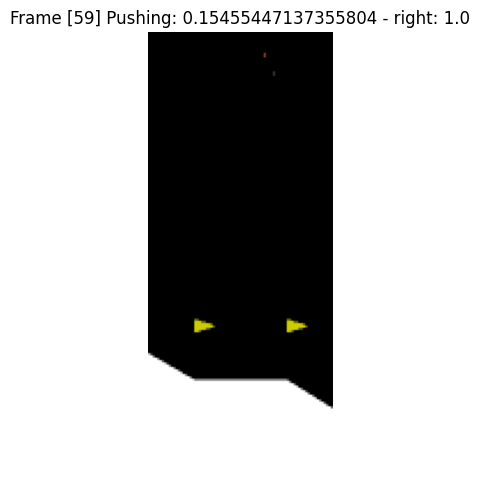

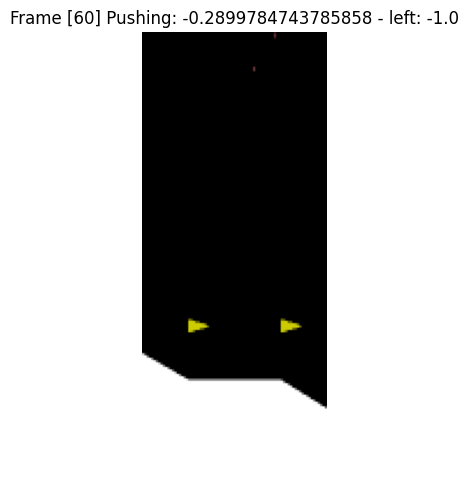

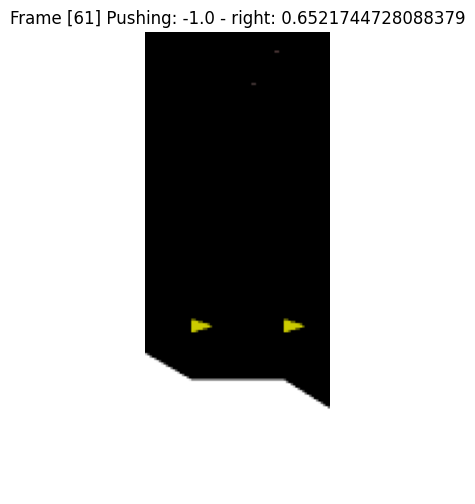

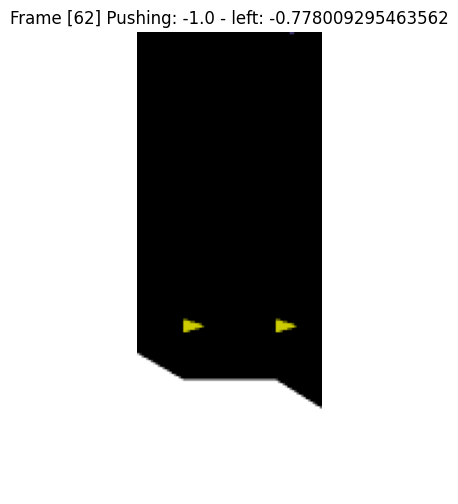

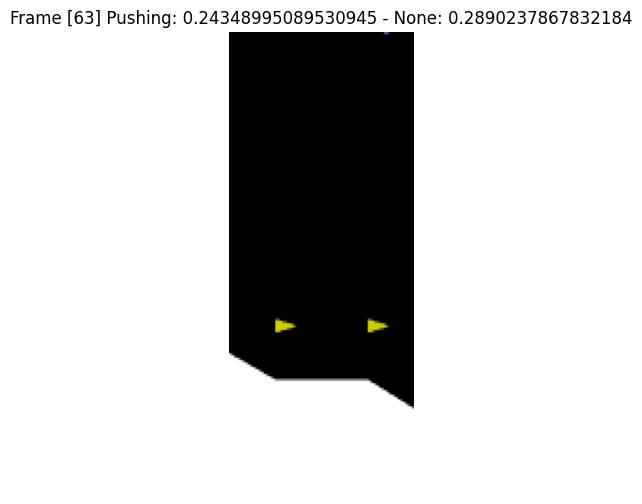

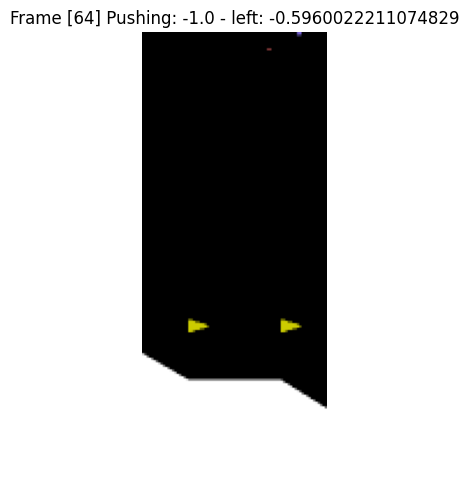

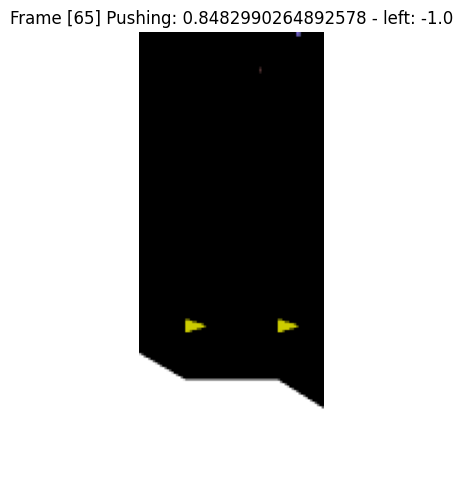

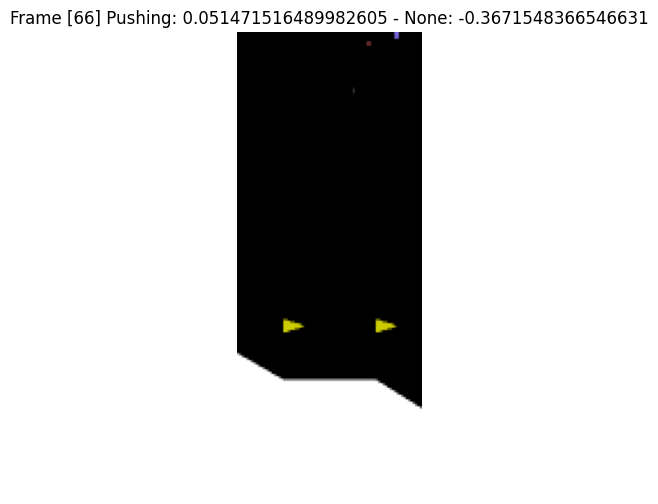

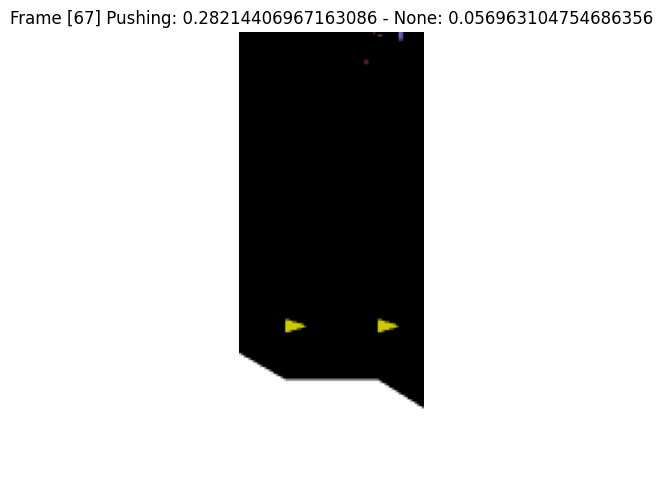

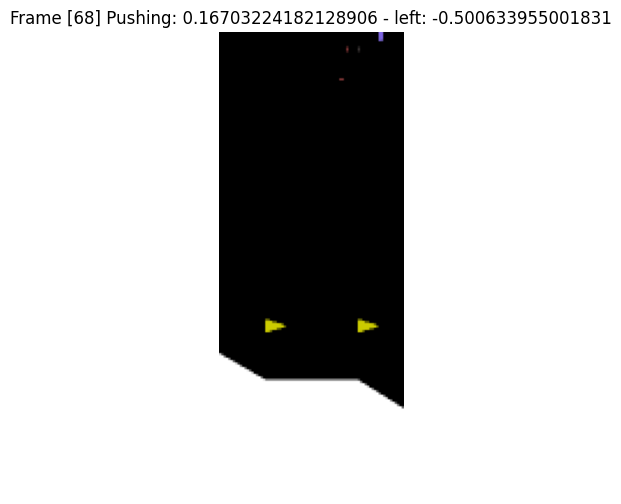

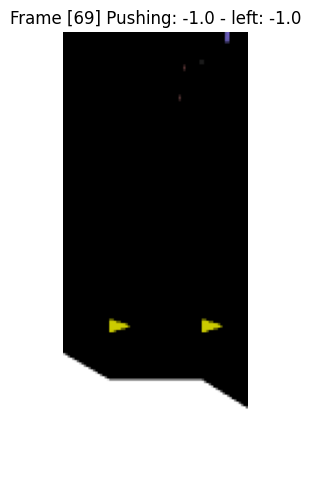

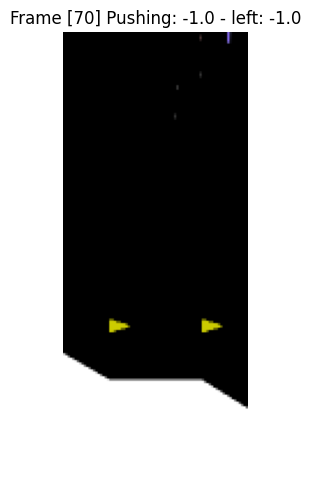

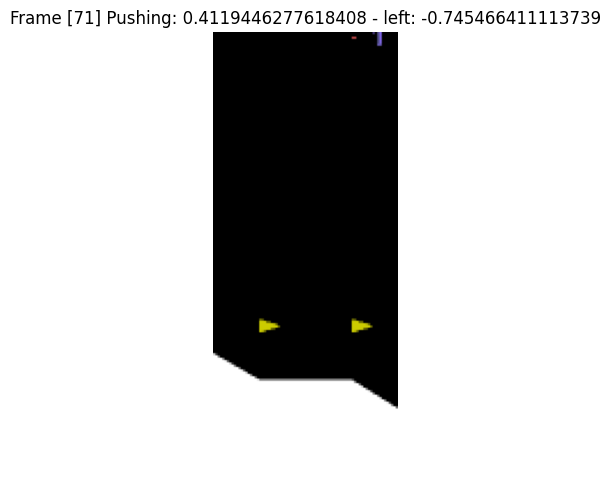

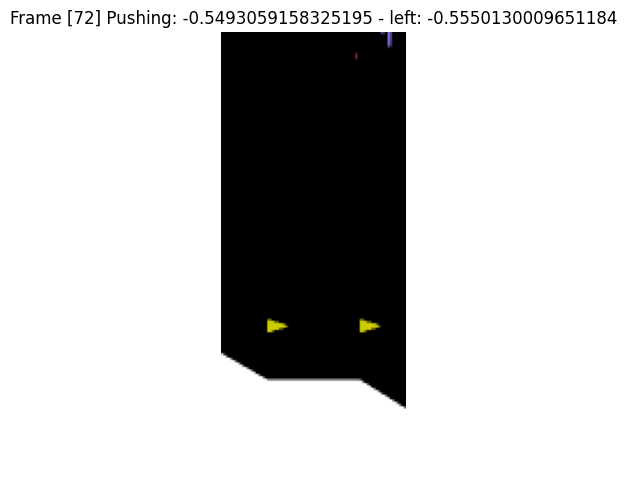

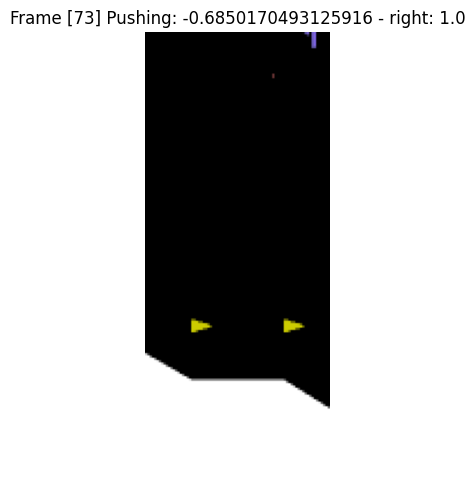

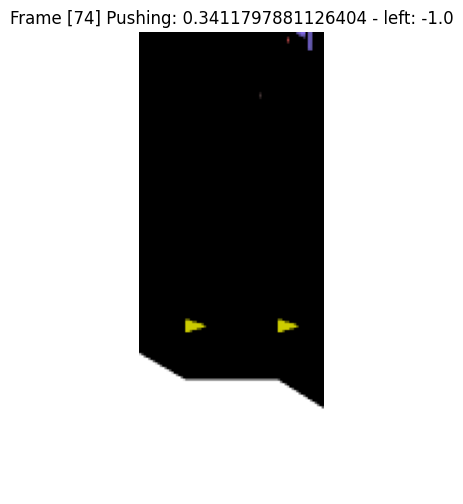

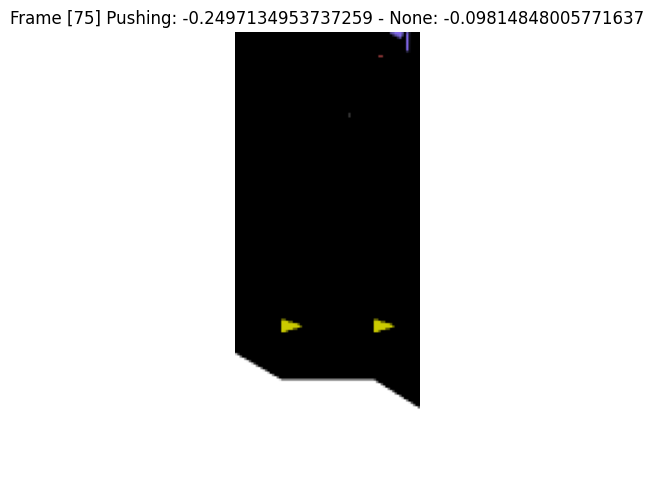

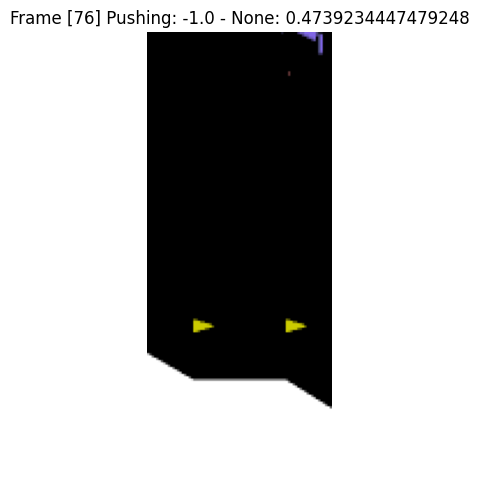

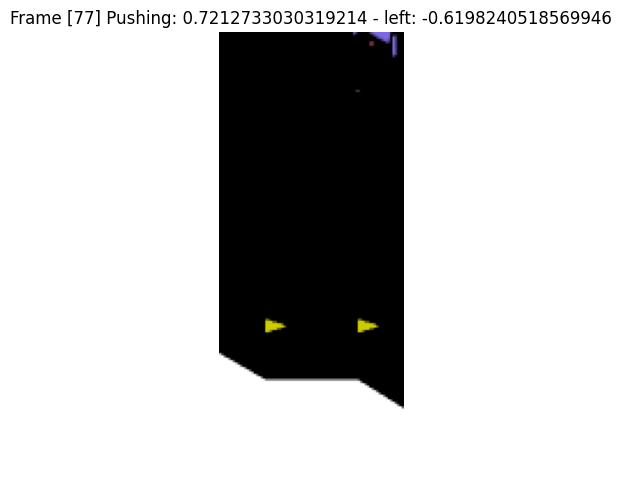

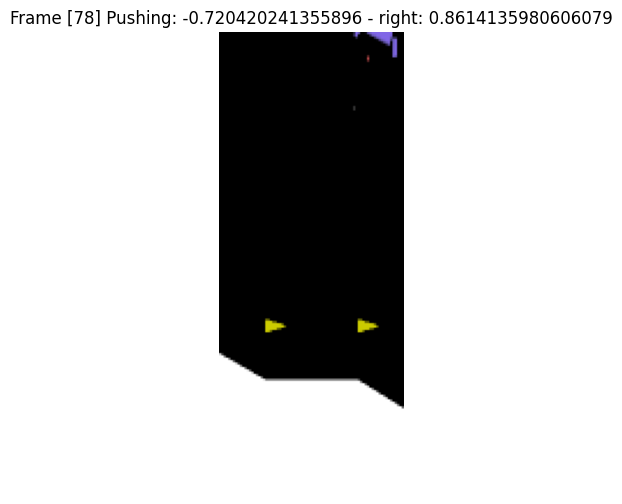

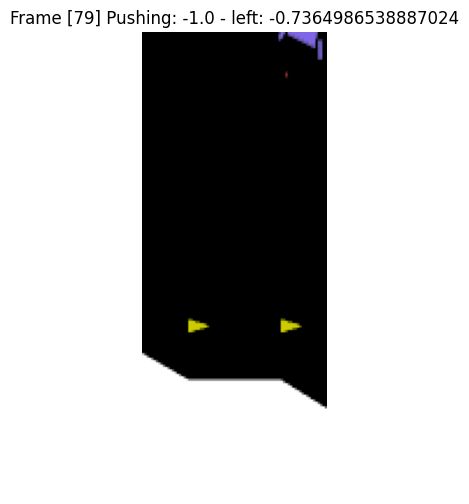

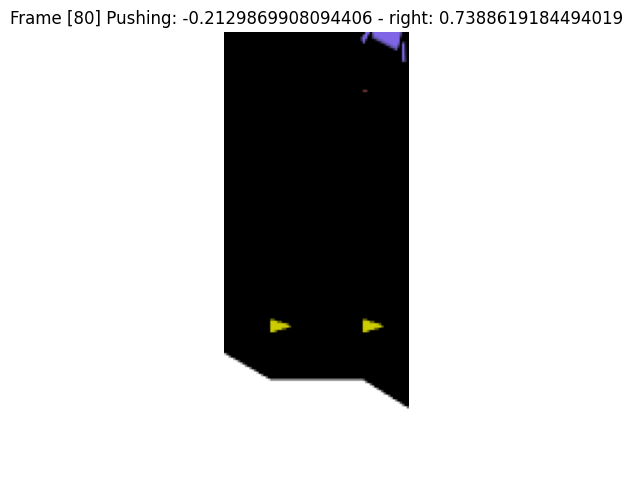

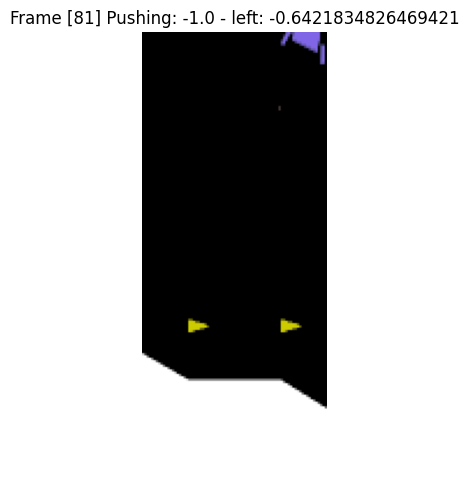

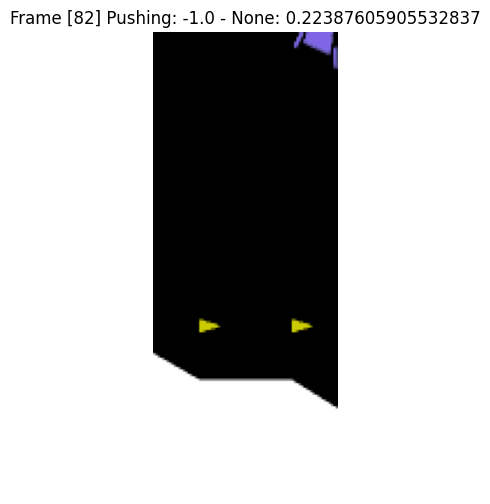

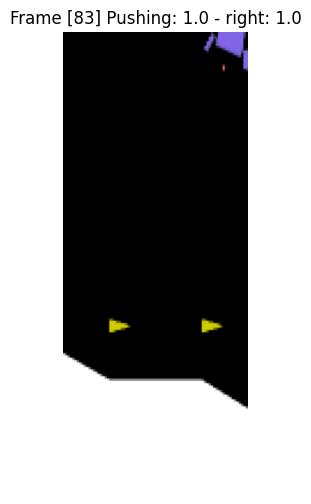

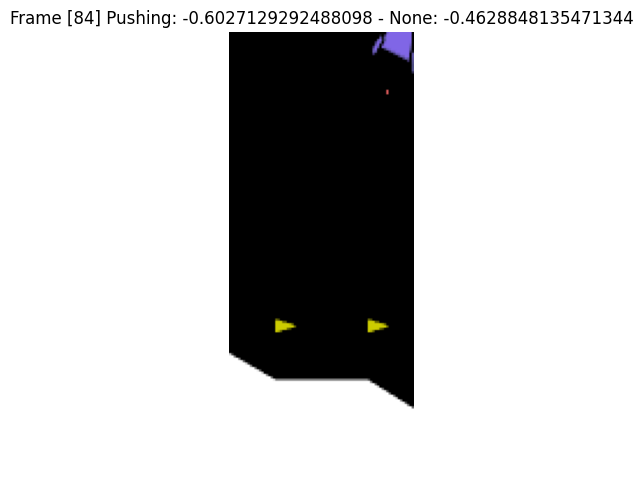

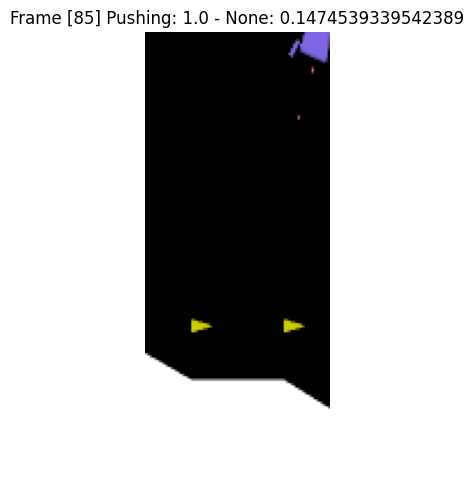

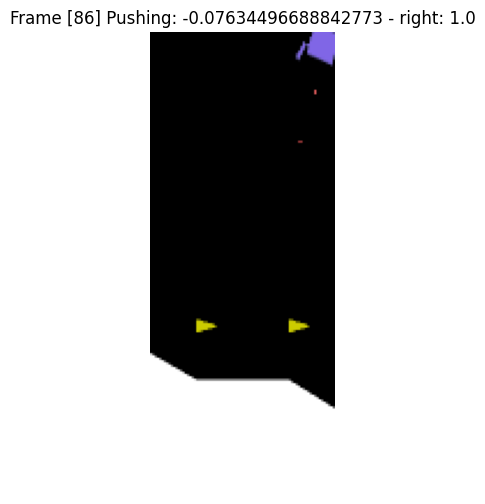

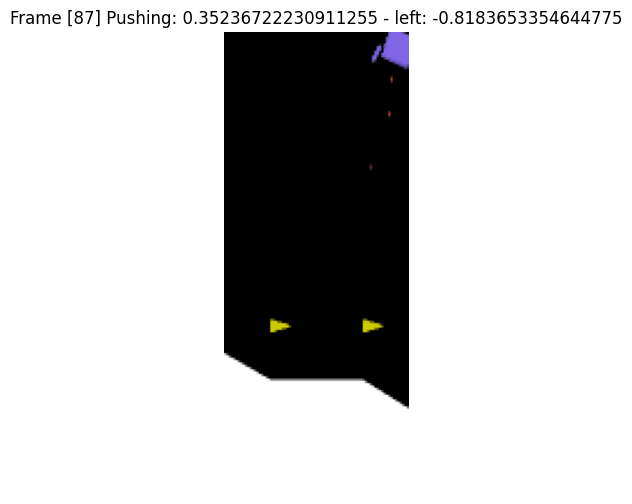

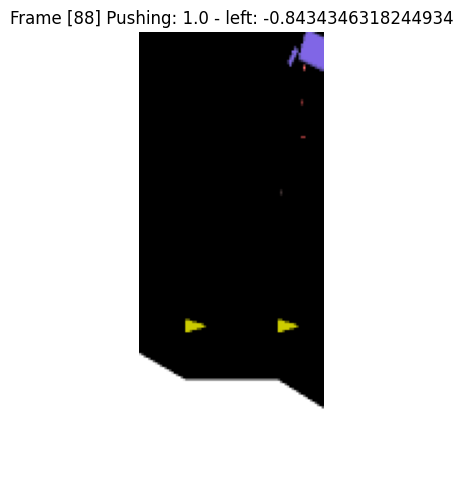

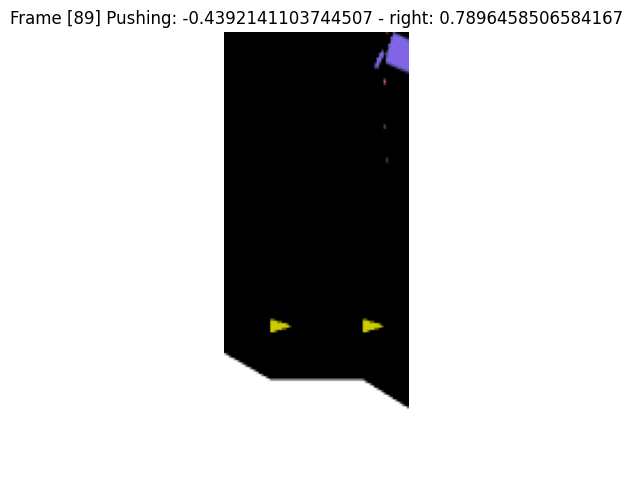

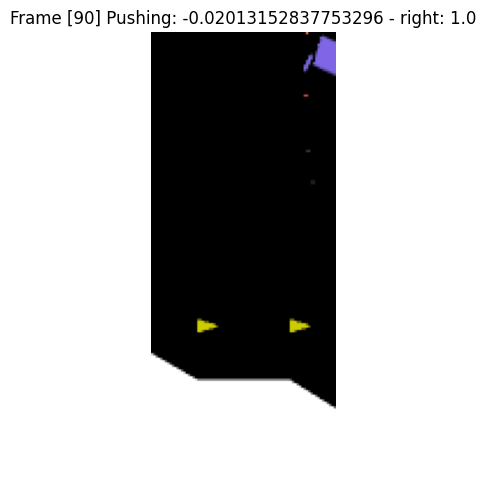

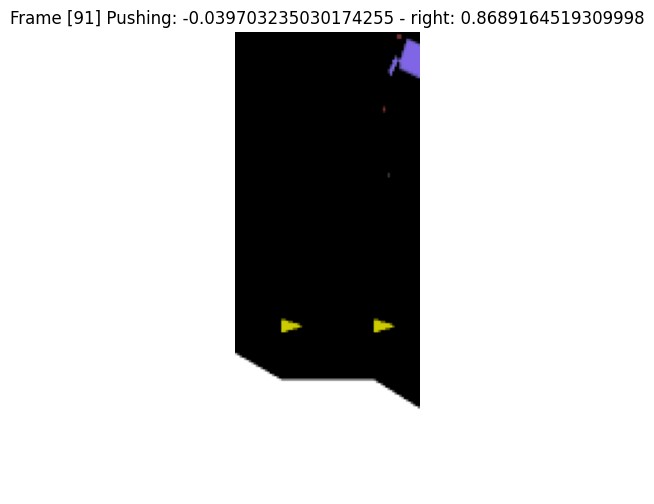

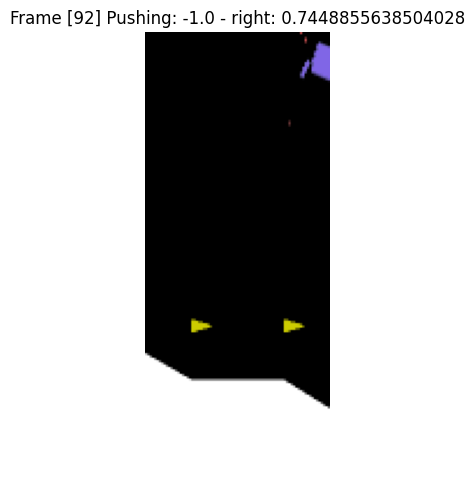

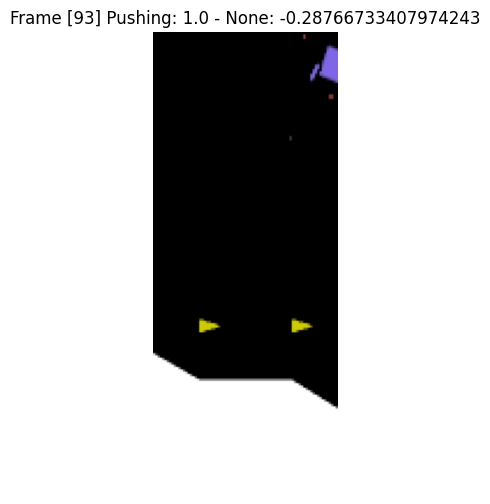

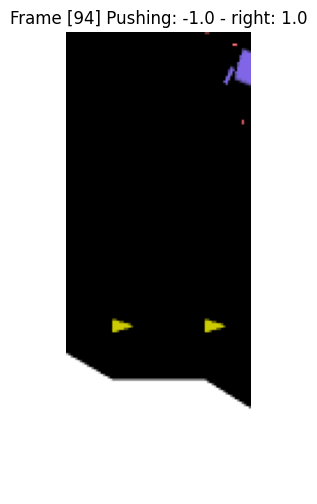

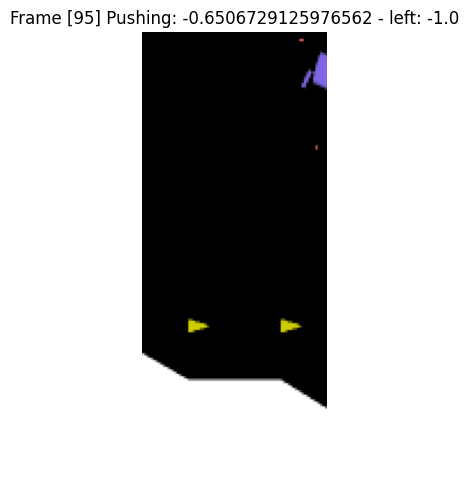

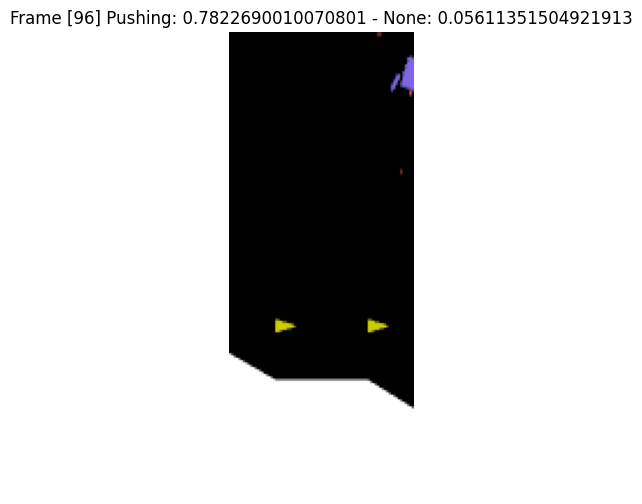

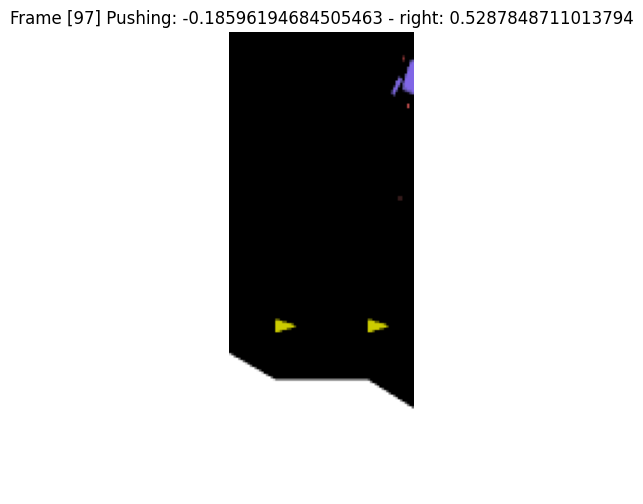

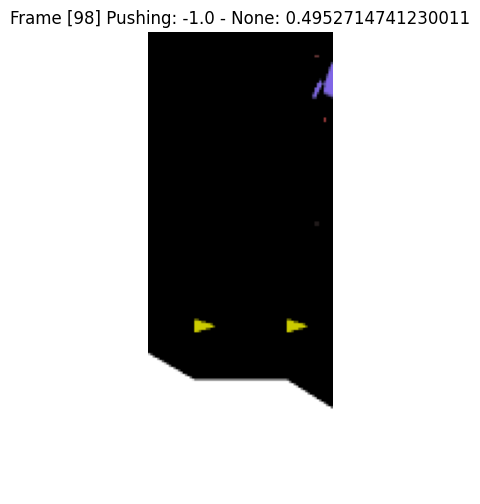

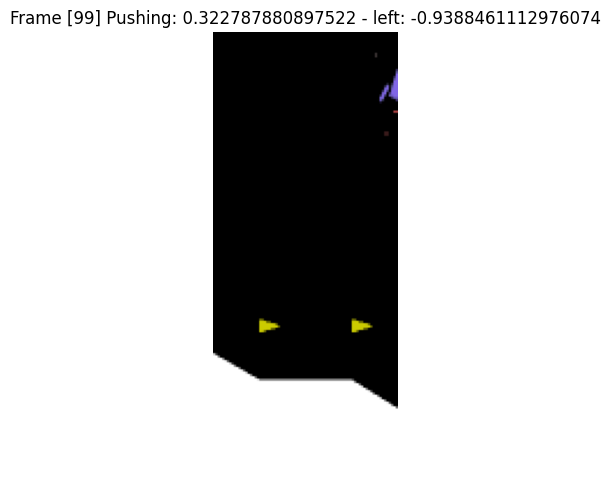

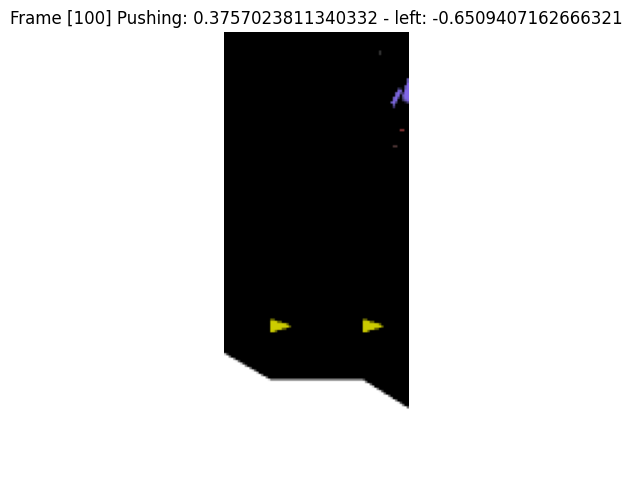

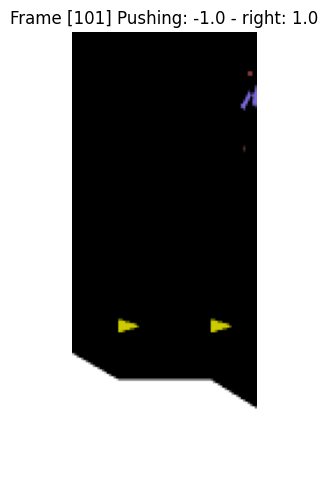

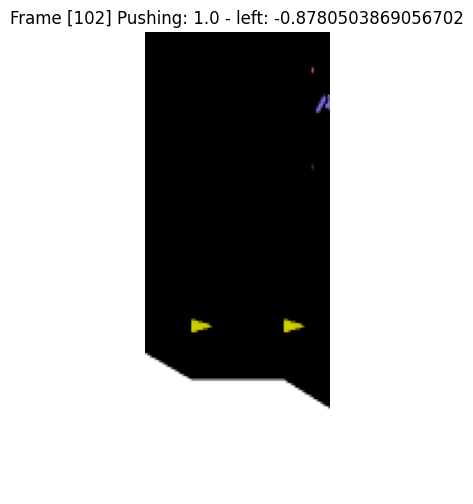

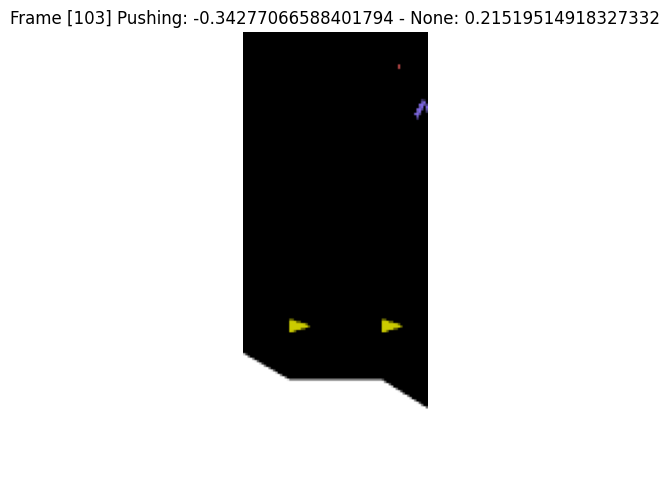

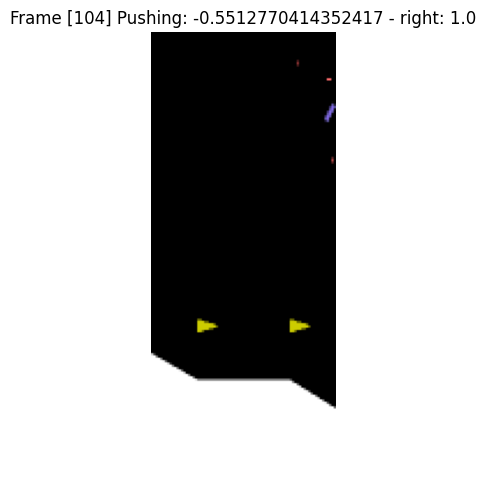

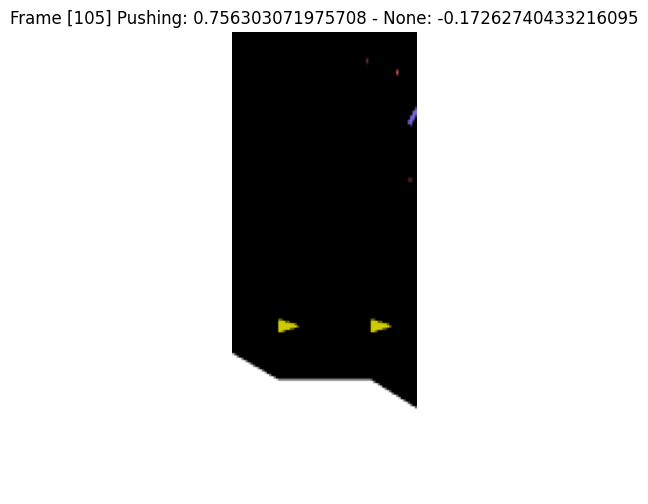

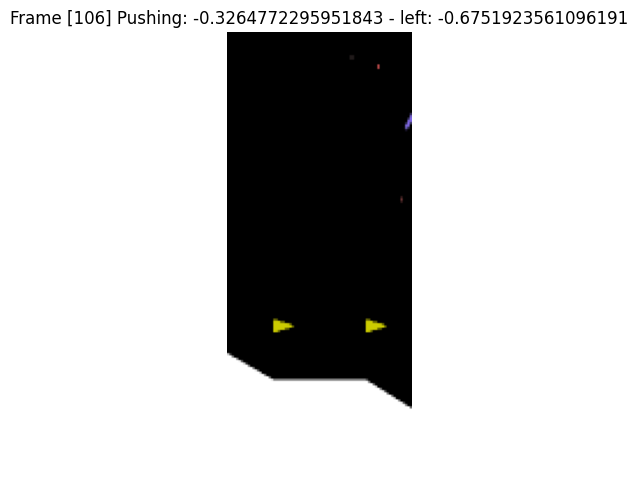

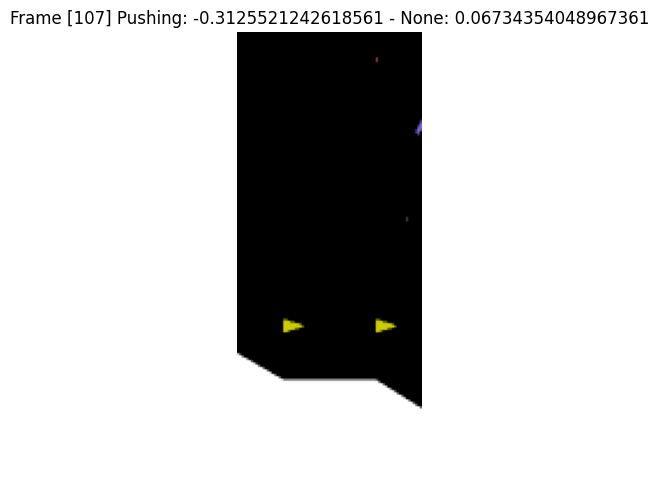

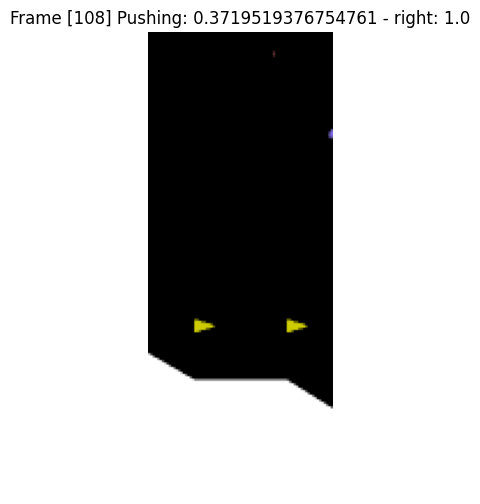

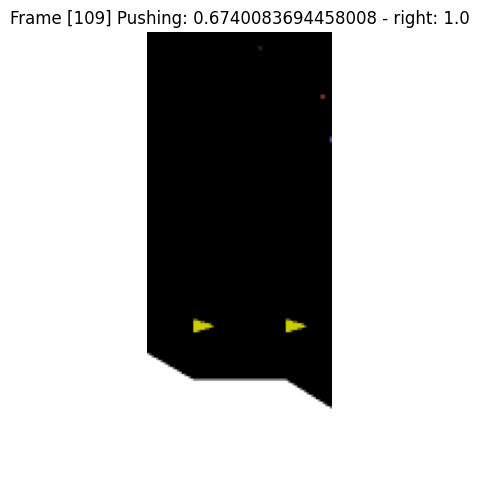

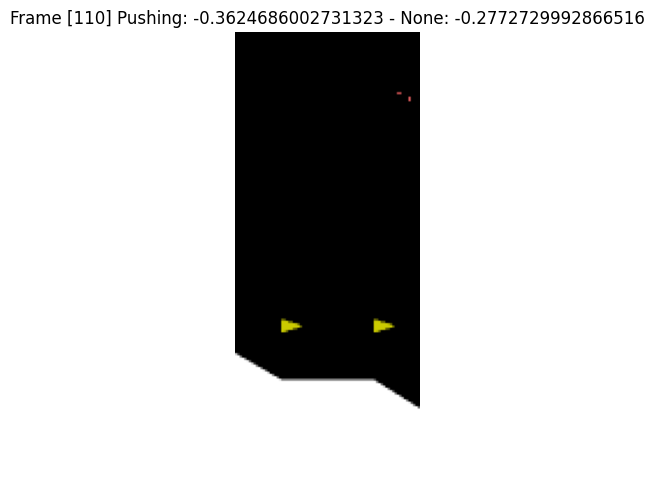

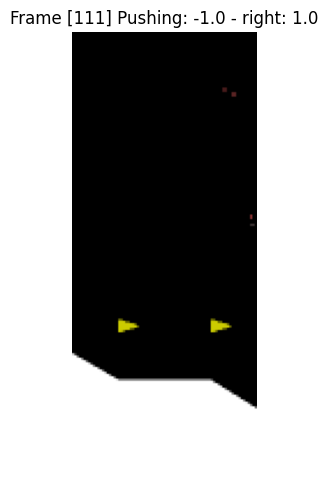

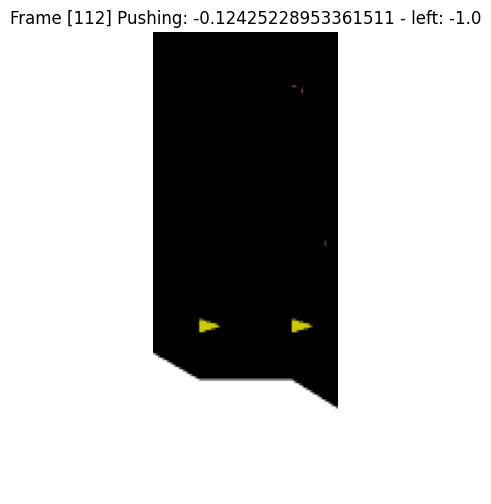

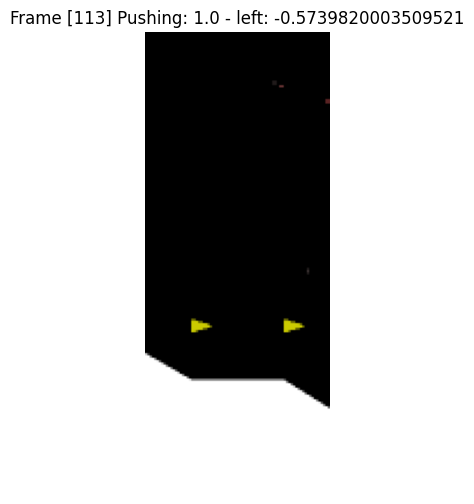

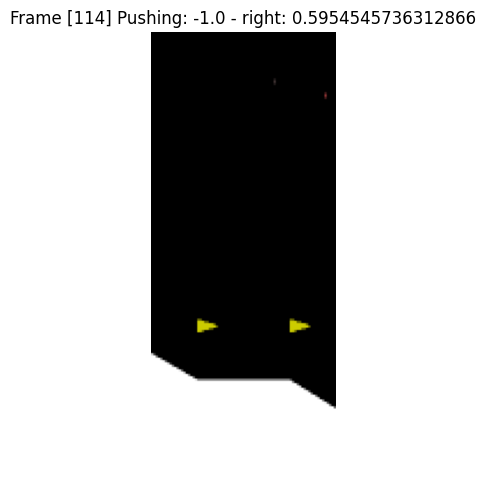

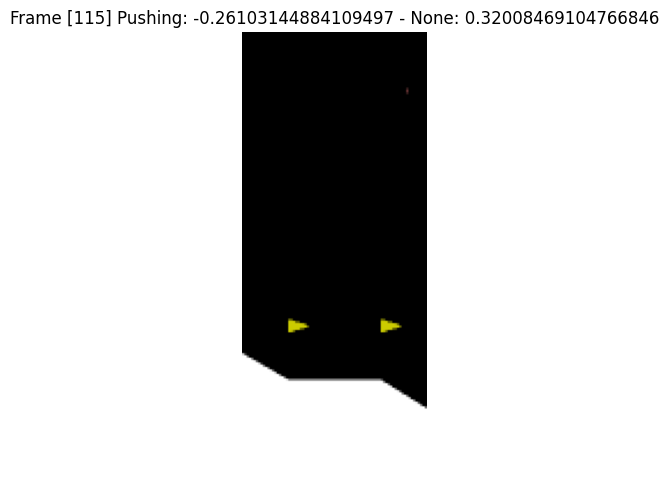

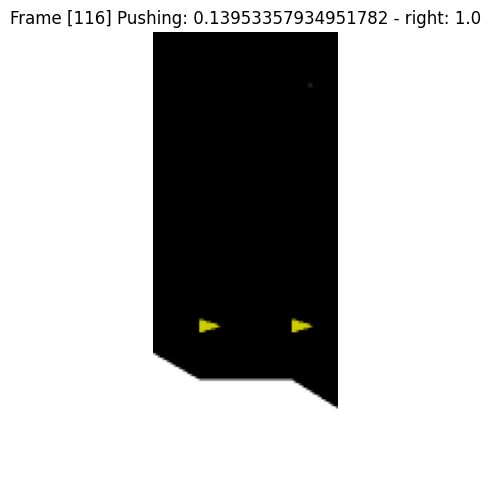

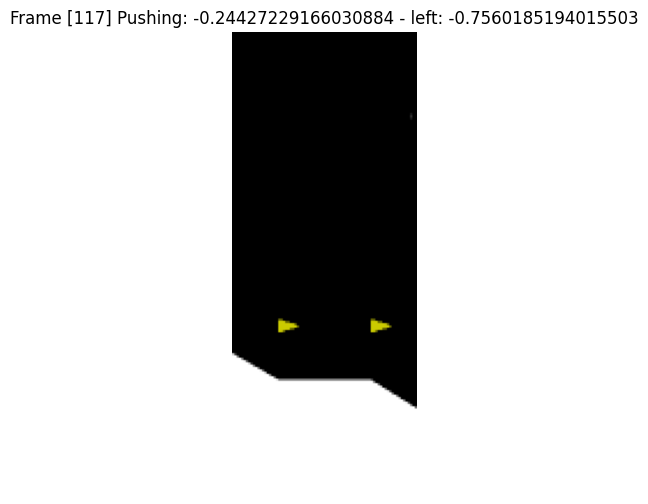

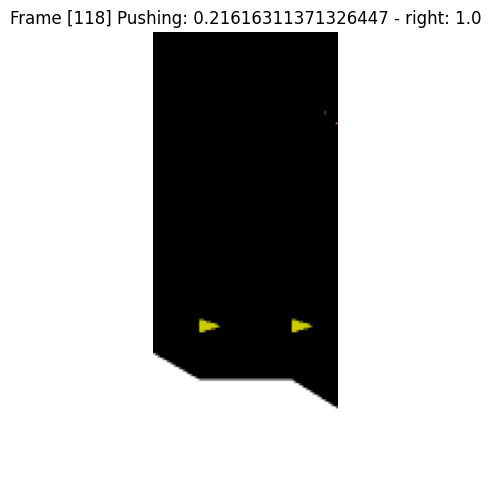

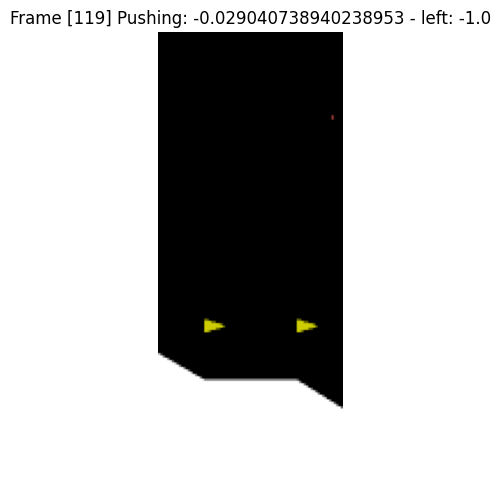

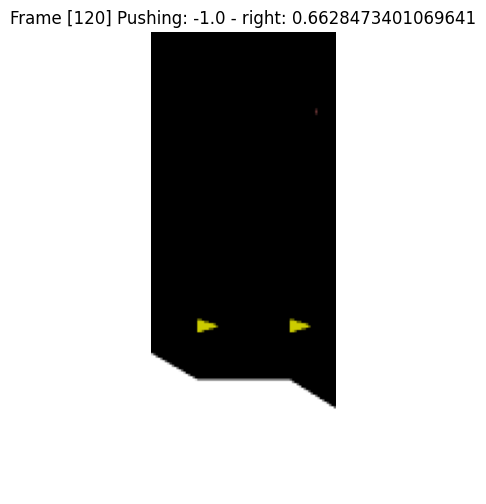

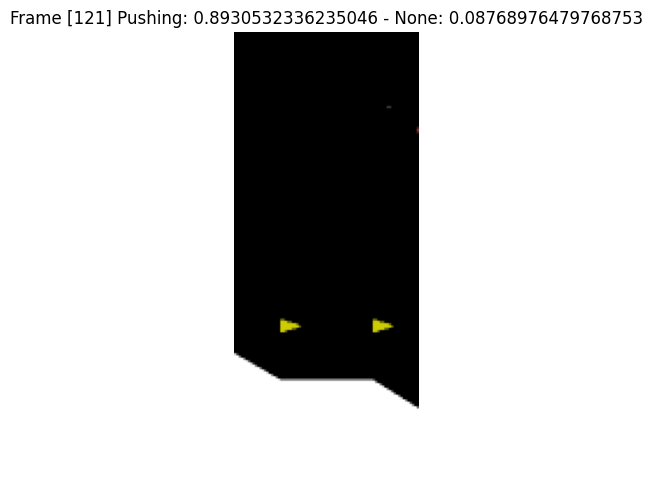

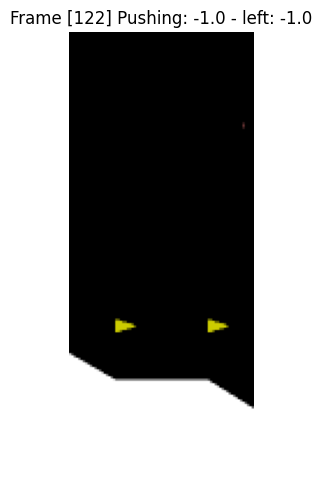

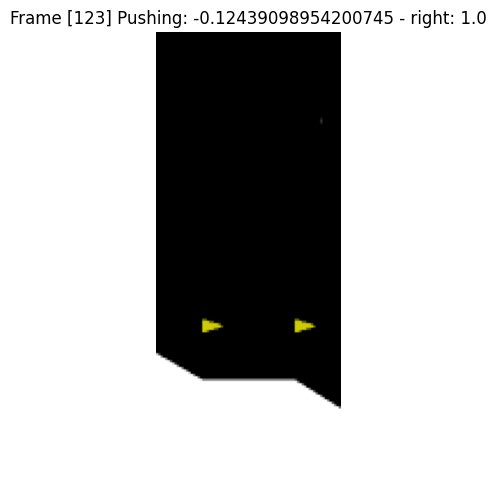

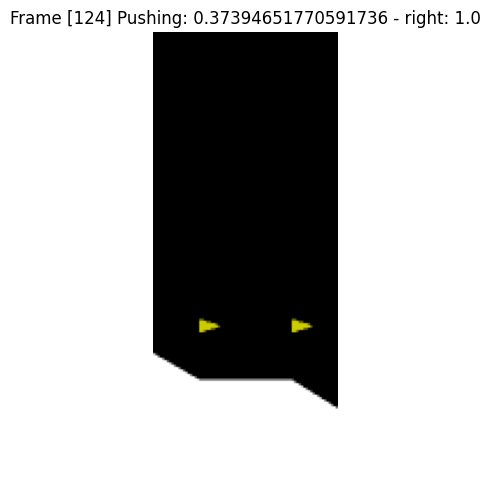

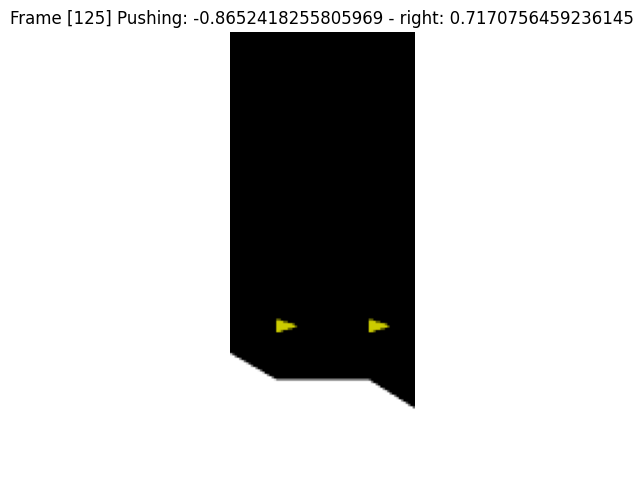

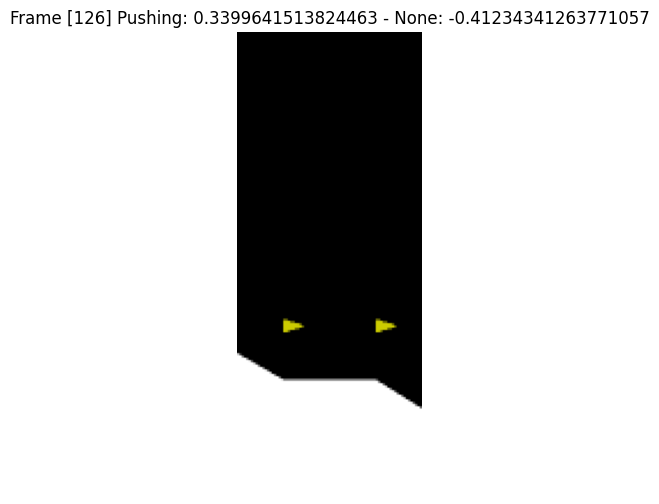

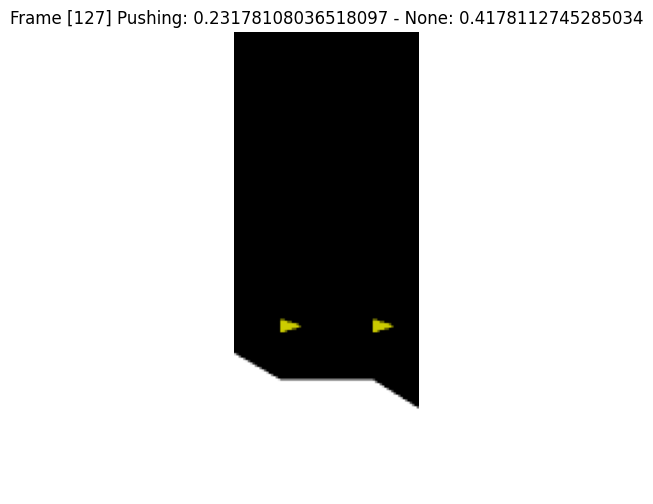

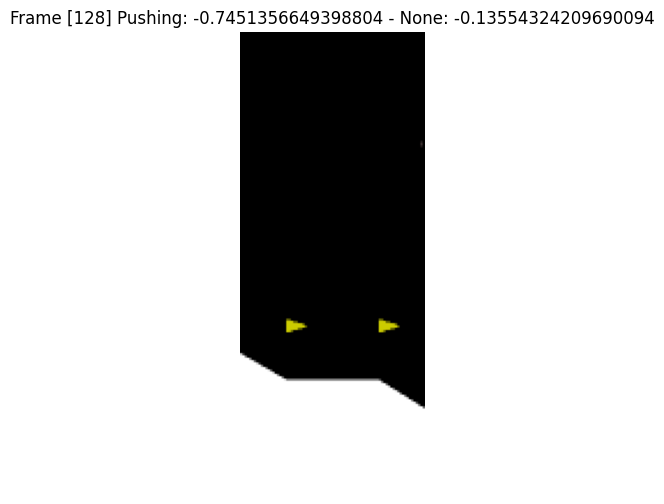

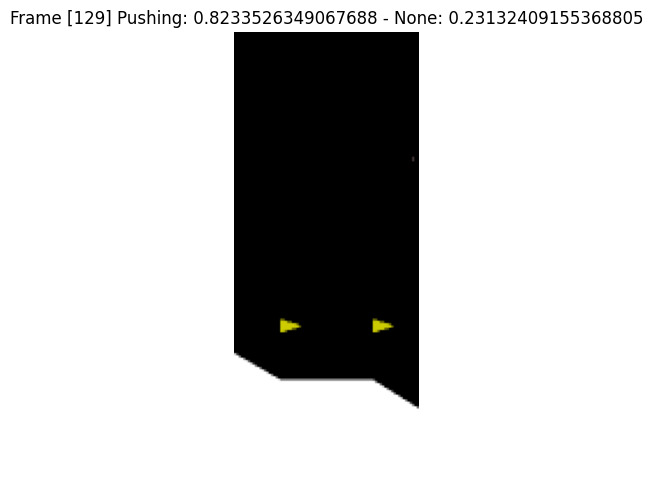

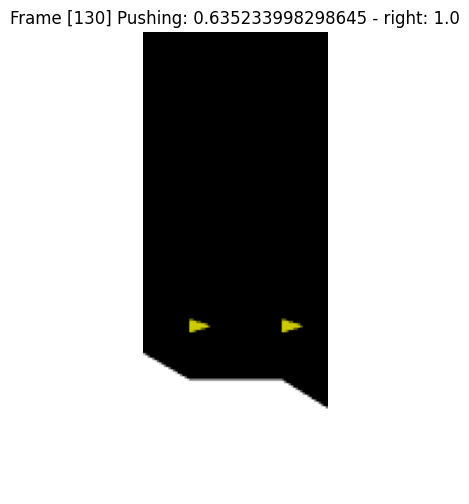

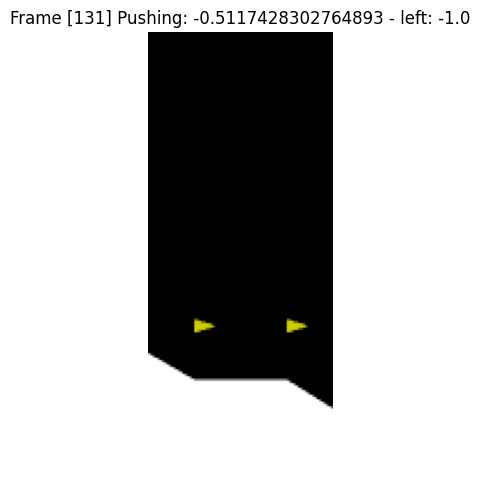

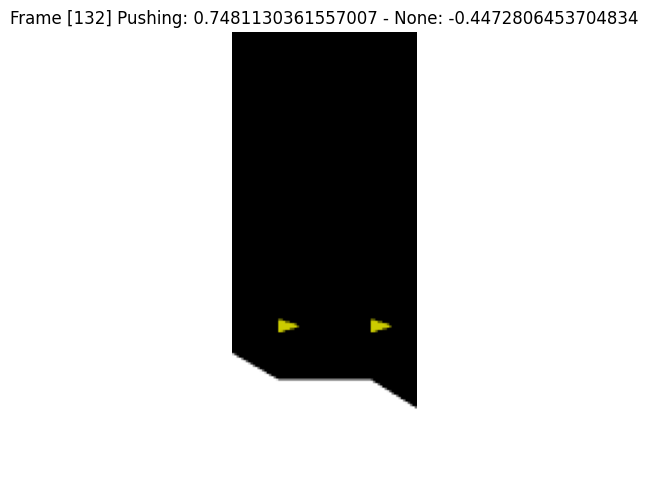

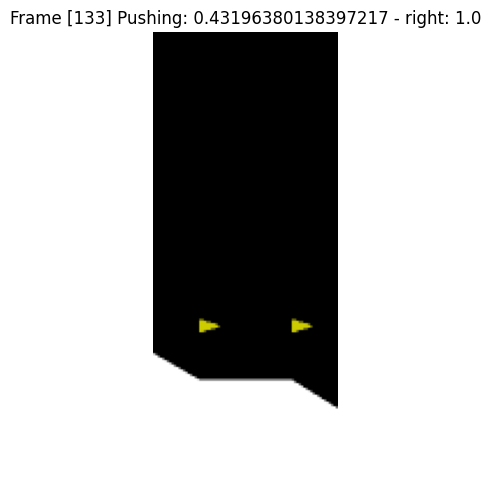

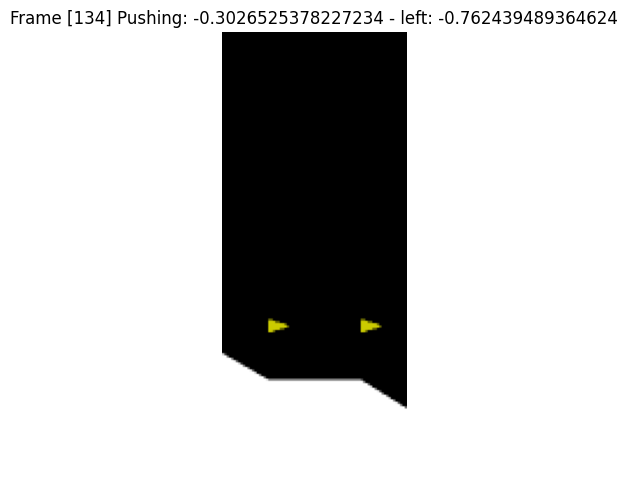

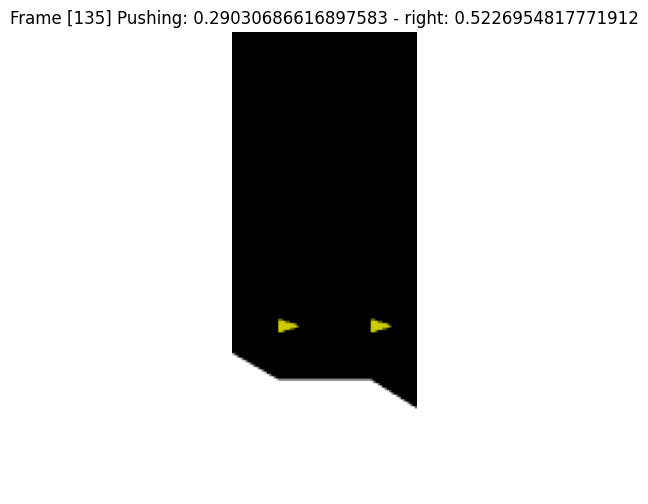

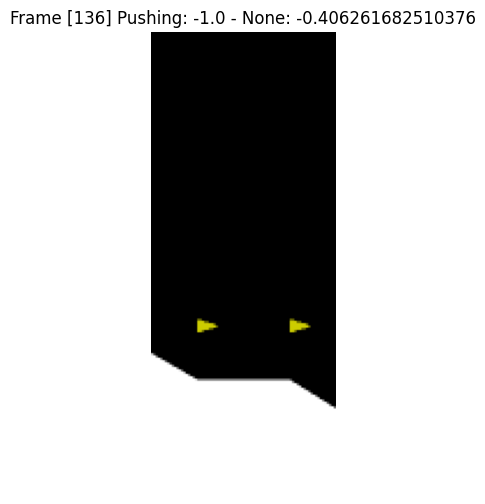

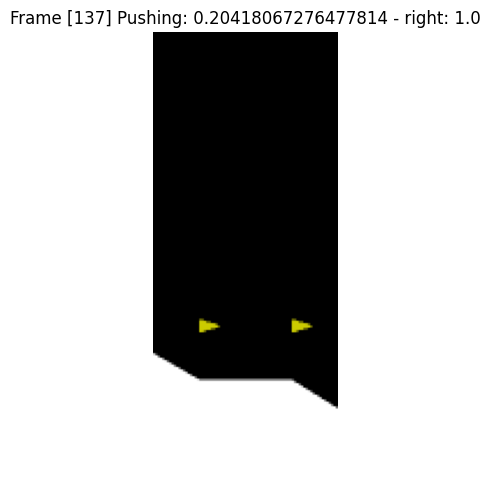

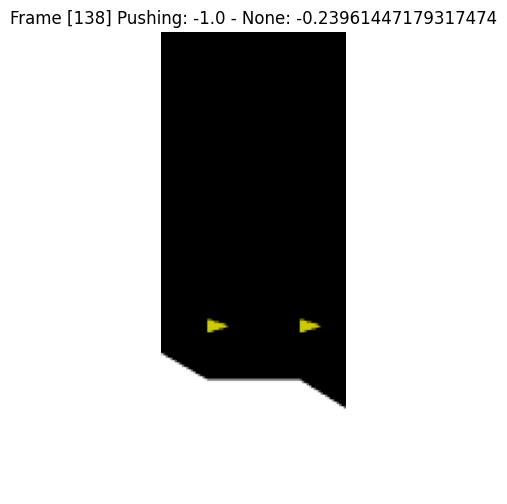

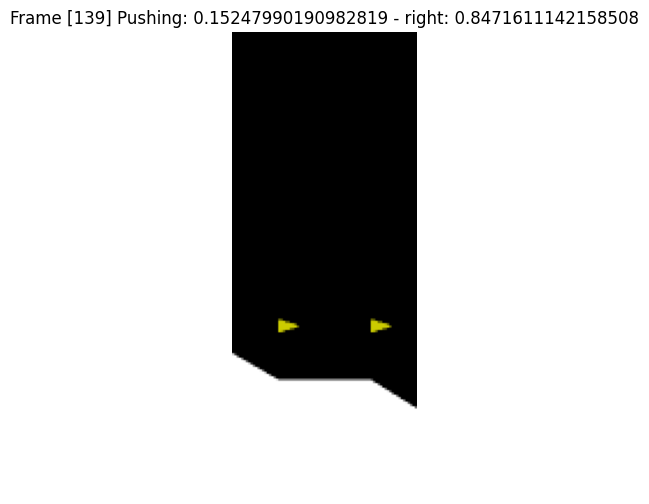

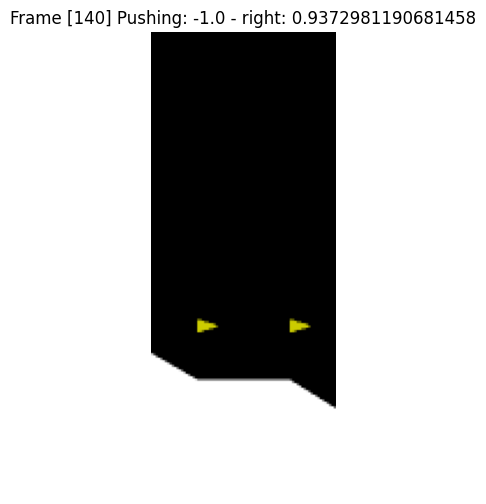

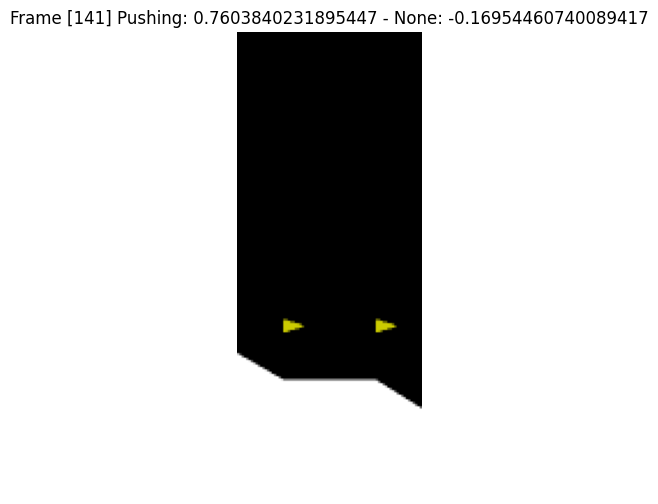

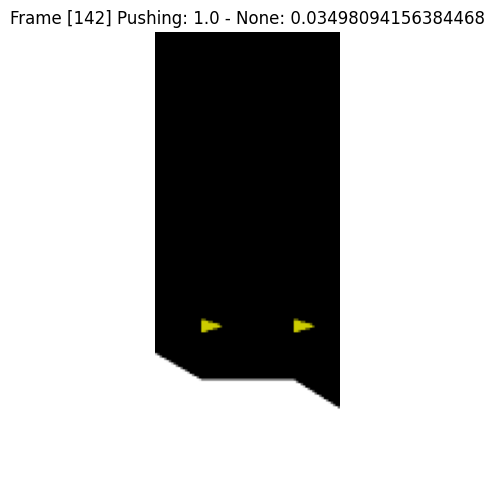

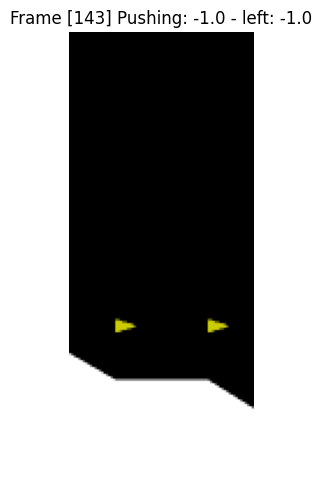

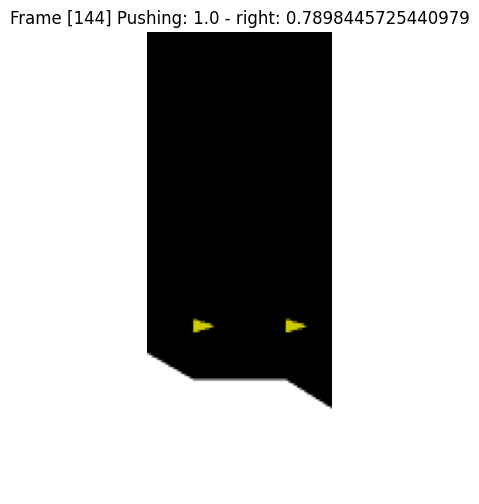

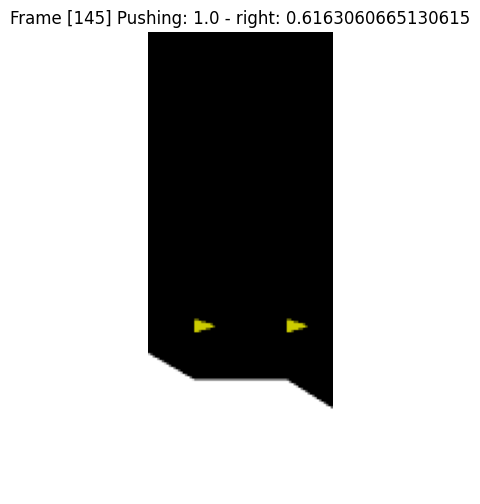

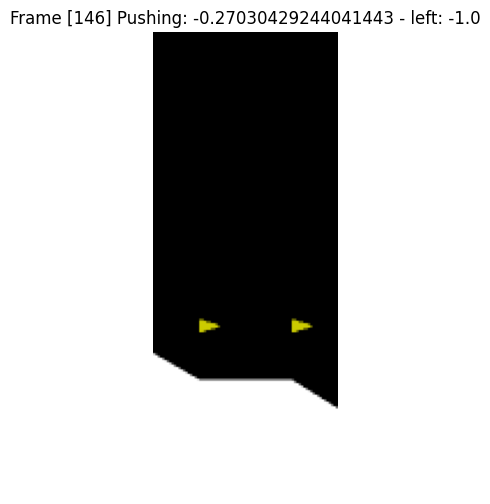

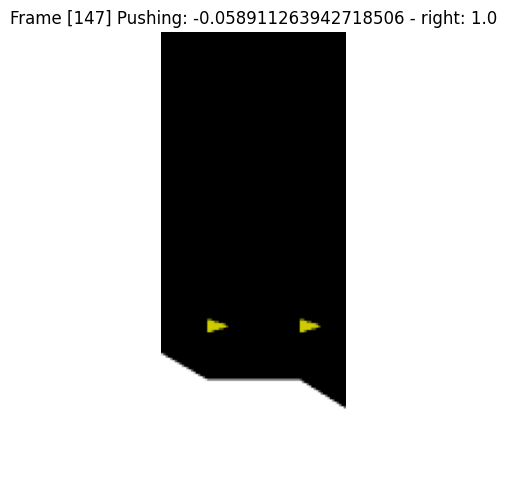

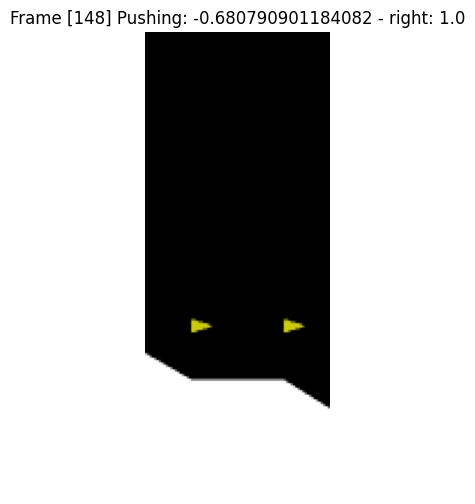

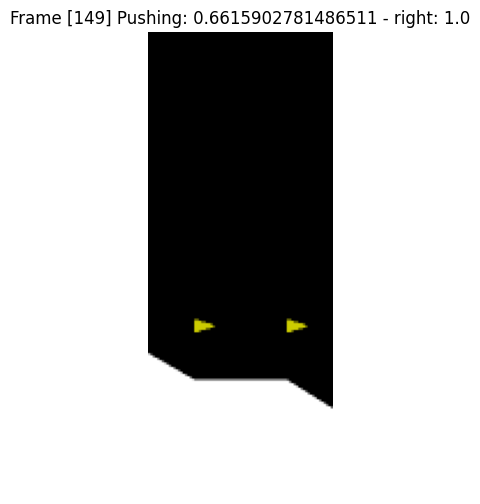

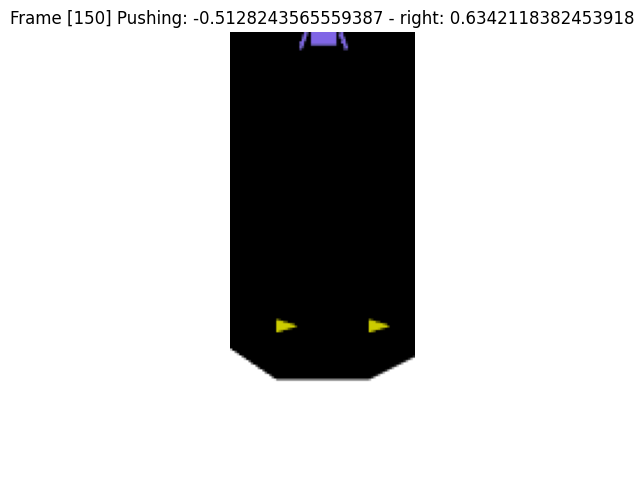

In [18]:
for i in range(len(df)):
    actions = np.squeeze(df.action[i])
    pushing = actions[0]
    side = "None"
    if actions[1] < -0.5:
        side = "left"
    elif actions[1] > 0.5:
        side = "right"
    
    plot_obs(df.state[i], 
             title=f"Frame [{i}] Pushing: {pushing} - {side}: {actions[1]}", 
             n_frame=1)

In [20]:
model_ckpt_2 = "../../run/ppo_vislunarlander_default/artifacts/best_checkpoint/ppo_vislunarlander_recurrent/2025-02-03 15-44-07/best_model"

model = RecurrentPPO.load(model_ckpt_2, device="cpu")

model

In [30]:
obs.shape

(1, 3, 200, 80)

In [31]:
import torch
import torchinfo

print(torchinfo.summary(model.policy.features_extractor, obs.shape, device="cpu"))
# print(model.policy.lstm_actor)
# torchinfo.summary(model.policy.lstm_actor, (1, 256), device="cpu")

Layer (type:depth-idx)                   Output Shape              Param #
FlattenExtractor                         [1, 48000]                --
├─Flatten: 1-1                           [1, 48000]                --
Total params: 0
Trainable params: 0
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0
Input size (MB): 0.19
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.19


In [32]:
from stable_baselines3.common.torch_layers import FlattenExtractor


def extract_feature(obs):
    model.predict(obs)

    obs_sample = torch.tensor(obs, dtype=torch.float32).to("cpu")
    cnn_model = model.policy.features_extractor

    if isinstance(cnn_model, FlattenExtractor):
        with torch.no_grad():
            layer_features = cnn_model(obs_sample)
            layer_features = {"layer1": layer_features}
    else:
        with torch.no_grad():
            layer_features = cnn_model.get_layer_features(obs_sample)

    return layer_features

layer_features = extract_feature(df.state[85])
layer_features.keys()


dict_keys(['layer1'])

In [33]:
print(df.state[50].shape)
print(layer_features["layer1"].numpy().shape)
# print(layer_features["layer2"].numpy().shape)
# print(layer_features["layer3"].numpy().shape)
output_shape = df.state.sample().to_numpy()[0].shape
layer_features["layer1"].numpy().reshape(output_shape[0], output_shape[2], output_shape[3], output_shape[1]).shape

(1, 3, 200, 80)
(1, 48000)


(1, 200, 80, 3)

In [34]:
def reshape_feature(feature):
    output_shape = df.state.sample().to_numpy()[0].shape
    return np.squeeze(feature.reshape(output_shape[0], output_shape[2], output_shape[3], output_shape[1]))

reshape_feature(layer_features["layer1"].numpy()).shape

(200, 80, 3)

In [35]:
torch.manual_seed(10)

In [36]:
def f(x):
    x



In [38]:
def plot_feature(index):
    obs = df.state[index]
    chosen_layer = "layer1"
    layer_features = extract_feature(obs)
    layer_features.keys()

    chosen_feature = layer_features[chosen_layer].numpy()

    fig, ax = plt.subplots(1, 2, figsize=(8, 6))

    feature_map = reshape_feature(layer_features["layer1"].numpy())
    ax[0].imshow(np.squeeze(obs).transpose(1,2,0), cmap="viridis")
    ax[1].imshow(feature_map, cmap="viridis")
    ax[1].axis("off")

    actions, _ = model.predict(obs, deterministic=0)
    actions = np.squeeze(actions)
    pushing = actions[0]
    side = "None"
    if actions[1] < -0.5:
        side = "left"
    elif actions[1] > 0.5:
        side = "right"

    fig.suptitle(f"Frame [{i}] Pushing: {pushing} - {side}: {actions[1]}", fontsize=18, fontweight='bold')
    plt.tight_layout()

interact(plot_feature, index=widgets.IntSlider(min=0, max=len(df)-1, step=1, value=85));

interactive(children=(IntSlider(value=85, description='index', max=150), Output()), _dom_classes=('widget-inte…

In [29]:
obs = df.state[85]
chosen_layer = "layer2"
layer_features = extract_feature(obs)
layer_features.keys()

nrow = layer_features[chosen_layer].numpy().shape[1]
ncol = np.ceil(nrow/4)
fig, ax = plt.subplots(4, ncol.astype(int), figsize=(15, 10))

for id in range(nrow):
    feature_map = layer_features[chosen_layer][0, id].detach().cpu().numpy()
    ax[int(id/ncol), int(id%ncol)].imshow(feature_map, cmap="viridis")
    ax[int(id/ncol), int(id%ncol)].axis("off")

actions, _ = model.predict(obs, deterministic=1)
actions = np.squeeze(actions)
pushing = actions[0]
side = "None"
if actions[1] < -0.5:
    side = "left"
elif actions[1] > 0.5:
    side = "right"

fig.suptitle(f"Frame [{i}] Pushing: {pushing} - {side}: {actions[1]}", fontsize=18, fontweight='bold')
plt.tight_layout()


KeyError: 'layer2'

# Check model parameters

In [22]:
from src.model.cnn import CustomCNN_2

In [ ]:
policy_kwargs = dict(
    features_extractor_class=CustomCNN_2,
    features_extractor_kwargs=dict(features_dim=256, num_frames=4)  # Adjust num_frames as needed
)

# Create the PPO agent using the custom feature extractor
checking_model = PPO(
    "CnnPolicy",
    env,
    policy_kwargs=policy_kwargs,
    verbose=1,
)

summary(checking_model.policy.features_extractor, obs[0].shape)

NameError: name 'PPO' is not defined